# Lipidomics — publication-ready figures

Input: `annotated_df.csv` (419 lipid species × 61 columns of log2 fold-changes and
adjusted p-values across multiple contrasts, plus `Ontology` lipid-class annotation).

Figures produced:
1. **Volcano plots** — low vs ctrl and osc vs ctrl (late combined), colored by lipid class.
2. **Class-level differential summary** — count of significantly up- and down-regulated
   species per lipid class.
3. **Class heatmap** — mean log2FC per ontology × contrast/timepoint.
4. **Top species bar chart** — top 15 up and top 15 down lipids per contrast.
5. **Class bubble plot** — mean log2FC vs class, sized by number of significant species.

All figures use Times New Roman, large fonts, no on-figure titles (caption-ready), and
save as PDF (vector) at 300 dpi.

## Setup

In [44]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# ---------- Publication style ----------
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          ["Times New Roman"],
    "mathtext.fontset":    "stix",
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
    "axes.labelsize":      22,
    "axes.titlesize":      20,
    "xtick.labelsize":     18,
    "ytick.labelsize":     18,
    "axes.linewidth":      1.3,
    "xtick.major.width":   1.3,
    "ytick.major.width":   1.3,
    "xtick.major.size":    6,
    "ytick.major.size":    6,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "legend.fontsize":     14,
    "legend.frameon":      False,
    "figure.dpi":          110,
    "savefig.dpi":         300,
    "savefig.bbox":        "tight",
})

# ---------- Load ----------
INPUT_CSV = Path("annotated_df.csv")
df = pd.read_csv(INPUT_CSV)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns="Unnamed: 0")

# Track LC-MS ionization mode (some species are measured in both)
df["polarity"] = df["lipid"].str.extract(r"_(Pos|Neg)$")[0]

print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
print(f"Unique lipid_clean: {df['lipid_clean'].nunique():,}")
print(f"Lipid classes: {df['Ontology'].nunique()}")
df.head(3)

Loaded 419 rows × 61 columns
Unique lipid_clean: 389
Lipid classes: 35


,lipid,low/control_3,low/control_3_ANOVA_p,low/control_3_ANOVA_padj,osc/control_3,osc/control_3_ANOVA_p,osc/control_3_ANOVA_padj,low/control_4,low/control_4_ANOVA_p,low/control_4_ANOVA_padj,...,ctrl_late/early_combined_ANOVA_padj,low_late/early_combined,low_late/early_combined_ANOVA_p,low_late/early_combined_ANOVA_padj,osc_late/early_combined,osc_late/early_combined_ANOVA_p,osc_late/early_combined_ANOVA_padj,lipid_clean,Ontology,polarity
0,13-Docosenamide_Pos,-0.446223,0.495475,0.991905,-0.339214,0.598220,0.995335,0.163880,0.711057,0.942124,...,0.092767,-0.043655,0.898061,0.929731,-1.104340,0.003979,0.008727,13-Docosenamide,Others,Pos
1,Benzyl butyl phthalate (also known as chemical...,0.389343,0.877690,0.991905,-2.027802,0.249676,0.995335,0.602397,0.546911,0.892831,...,0.630081,0.387002,0.665942,0.743755,-0.520304,0.473414,0.501696,Benzyl butyl phthalate (also known as chemical...,Others,Pos
2,CL 68:4|CL 16:1_18:1_16:1_18:1_Neg,-0.362308,0.462071,0.991905,-0.189351,0.642093,0.995335,1.613961,0.028034,0.264706,...,0.000476,1.509145,0.001088,0.003908,-2.059234,0.001000,0.002916,CL 68:4|CL 16:1_18:1_16:1_18:1,CL,Neg


## Handle Pos/Neg duplicates

A few species are measured in both ionization modes. For per-class summaries and
heatmaps we want one row per molecular species, so we keep the measurement with the
**lower median adjusted p-value across all comparisons** (i.e., the more reliable
signal). For the volcano plots we use the deduplicated table too, since plotting both
modes would double-count those species.

In [45]:
padj_cols = [c for c in df.columns if c.endswith("_ANOVA_padj")]
df["_padj_median"] = df[padj_cols].median(axis=1, skipna=True)

# Within each lipid_clean, keep the row with lowest median padj
dedup = (df.sort_values("_padj_median")
           .drop_duplicates(subset="lipid_clean", keep="first")
           .drop(columns="_padj_median")
           .reset_index(drop=True))

n_dup = len(df) - len(dedup)
print(f"Collapsed {n_dup} duplicate rows (Pos/Neg or otherwise) → {len(dedup):,} unique species")

# Save raw and deduped both — most downstream work uses `dedup`
df = df.drop(columns="_padj_median")

Collapsed 30 duplicate rows (Pos/Neg or otherwise) → 389 unique species


## Define contrasts

The CSV holds many comparisons; here we set up the canonical set used in the figures.
Change `PRIMARY_CONTRASTS` to highlight a different one.

In [46]:
# Each entry: short label → (log2FC column, padj column, display label)
CONTRASTS = {
    "low_late":  ("low/control_late_combined",  "low/control_late_combined_ANOVA_padj",  "Low vs Ctrl (late)"),
    "osc_late":  ("osc/control_late_combined",  "osc/control_late_combined_ANOVA_padj",  "Osc vs Ctrl (late)"),
    "low_early": ("low/control_early_combined", "low/control_early_combined_ANOVA_padj", "Low vs Ctrl (early)"),
    "osc_early": ("osc/control_early_combined", "osc/control_early_combined_ANOVA_padj", "Osc vs Ctrl (early)"),
    "late_early":('ctrl_late/early_combined','ctrl_late/early_combined_ANOVA_padj', "Late vs Early"),
                  }
PRIMARY_CONTRASTS = ["low_late", "osc_late","late_early"]  # used by figures 1, 2, 4, 5
Ctrl_Contrasts = ['late_early']
ALPHA          = 0.05            # padj cutoff
FC_THRESHOLD   = np.log2(1.5)    # |log2FC| cutoff → 0.585 (≈ 1.5× change)
print(f"Significance: padj < {ALPHA} AND |log2FC| > {FC_THRESHOLD:.3f}  (1.5× fold change)")

Significance: padj < 0.05 AND |log2FC| > 0.585  (1.5× fold change)


## Figure 1 — Volcano plots (Low vs Ctrl, Osc vs Ctrl, late combined)

Each point is one lipid species, colored by ontology class. Dashed lines mark the
significance thresholds; the top labeled species are the strongest hits in each
contrast.

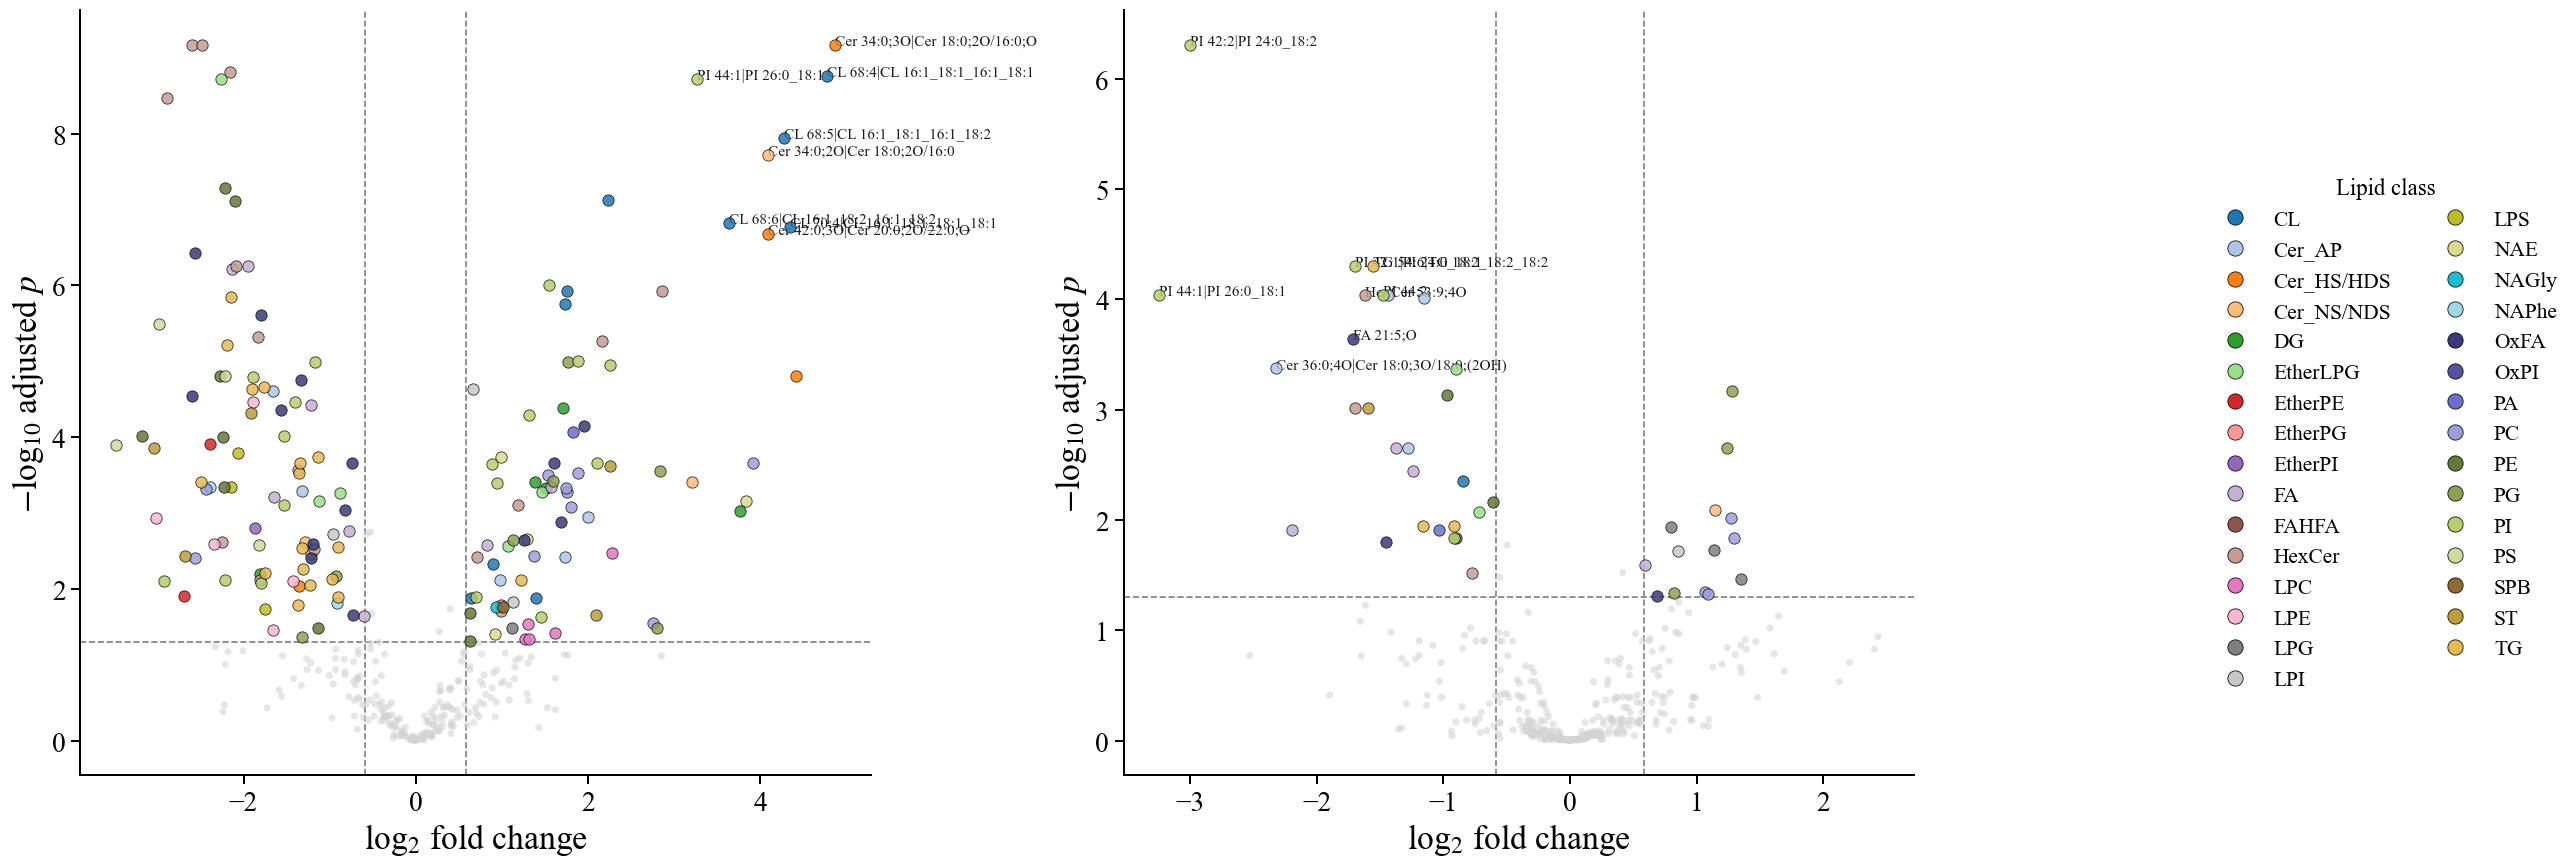


Low vs Ctrl (late)         n_up =  79   n_down =  91
Osc vs Ctrl (late)         n_up =  14   n_down =  28
Late vs Early              n_up = 112   n_down = 105


In [21]:
# A reproducible class color palette
def class_palette(classes):
    n = len(classes)
    # tab20 has 20 distinguishable hues; we have ~35 classes, so combine with tab20b
    cmap = (list(plt.get_cmap("tab20").colors)
            + list(plt.get_cmap("tab20b").colors)
            + list(plt.get_cmap("tab20c").colors))
    return {c: cmap[i % len(cmap)] for i, c in enumerate(classes)}


def build_volcano_table(d, fc_col, padj_col):
    out = d[["lipid_clean", "Ontology", fc_col, padj_col]].dropna().copy()
    out = out.rename(columns={fc_col: "log2FC", padj_col: "padj"})
    out["neglog10_padj"] = -np.log10(out["padj"].replace(0, np.nextafter(0, 1)))
    out["sig"] = (out["padj"] <= ALPHA) & (out["log2FC"].abs() >= FC_THRESHOLD)
    return out


def plot_volcano(ax, vt, palette, label_top_n=10):
    # Non-significant points: gray, small, transparent
    ns = vt[~vt["sig"]]
    ax.scatter(ns["log2FC"], ns["neglog10_padj"],
               s=22, color="lightgray", edgecolor="none", alpha=0.55, zorder=2)

    # Significant points: color by class, larger
    sig = vt[vt["sig"]]
    for cls, sub in sig.groupby("Ontology"):
        ax.scatter(sub["log2FC"], sub["neglog10_padj"],
                   s=55, color=palette.get(cls, "black"),
                   edgecolor="black", linewidth=0.5, alpha=0.85,
                   zorder=4, label=cls)

    # Threshold lines
    ax.axhline(-np.log10(ALPHA), linestyle="--", color="gray", linewidth=1.1, zorder=1)
    ax.axvline( FC_THRESHOLD,  linestyle="--", color="gray", linewidth=1.1, zorder=1)
    ax.axvline(-FC_THRESHOLD,  linestyle="--", color="gray", linewidth=1.1, zorder=1)

    # Label top N species by combined rank (significance + magnitude)
    sig = sig.copy()
    sig["score"] = sig["neglog10_padj"] * sig["log2FC"].abs()
    top = sig.nlargest(label_top_n, "score")
    texts = [ax.text(r["log2FC"], r["neglog10_padj"], r["lipid_clean"],
                     fontsize=10, alpha=0.9)
             for _, r in top.iterrows()]
    try:
        from adjustText import adjust_text
        adjust_text(texts, ax=ax,
                    arrowprops=dict(arrowstyle="-", color="gray", lw=0.6),
                    expand=(1.2, 1.4), force_text=(0.3, 0.4))
    except ImportError:
        pass  # fall back to overlapping labels if adjustText unavailable

    ax.set_xlabel("log$_2$ fold change", fontsize=22)
    ax.set_ylabel("$-$log$_{10}$ adjusted $p$", fontsize=22)


# Gather classes present across the two primary contrasts and assign colors
vt_dict = {k: build_volcano_table(dedup, *CONTRASTS[k][:2]) for k in PRIMARY_CONTRASTS}
all_sig_classes = sorted({c for k in PRIMARY_CONTRASTS for c in vt_dict[k].loc[vt_dict[k]["sig"], "Ontology"].unique()})
palette = class_palette(all_sig_classes)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, key in zip(axes, PRIMARY_CONTRASTS):
    plot_volcano(ax, vt_dict[key], palette, label_top_n=8)

# Right-side legend — one per class shown across both panels
handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=10,
                      markerfacecolor=palette[c], markeredgecolor="black",
                      markeredgewidth=0.5, label=c)
           for c in all_sig_classes]
ncol_legend = 2 if len(handles) > 15 else 1
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5),
           ncol=ncol_legend, fontsize=14, title="Lipid class", title_fontsize=15)

fig.tight_layout(rect=[0, 0, 0.93 if ncol_legend == 1 else 0.88, 1])
# fig.savefig("fig1_volcano.pdf")
plt.show()

# Print summary counts
print()
for key in PRIMARY_CONTRASTS:
    vt = vt_dict[key]
    n_up = ((vt["sig"]) & (vt["log2FC"] > 0)).sum()
    n_dn = ((vt["sig"]) & (vt["log2FC"] < 0)).sum()
    print(f"{CONTRASTS[key][2]:25s}  n_up = {n_up:3d}   n_down = {n_dn:3d}")

In [22]:
PRIMARY_CONTRASTS

['low_late', 'osc_late', 'late_early']

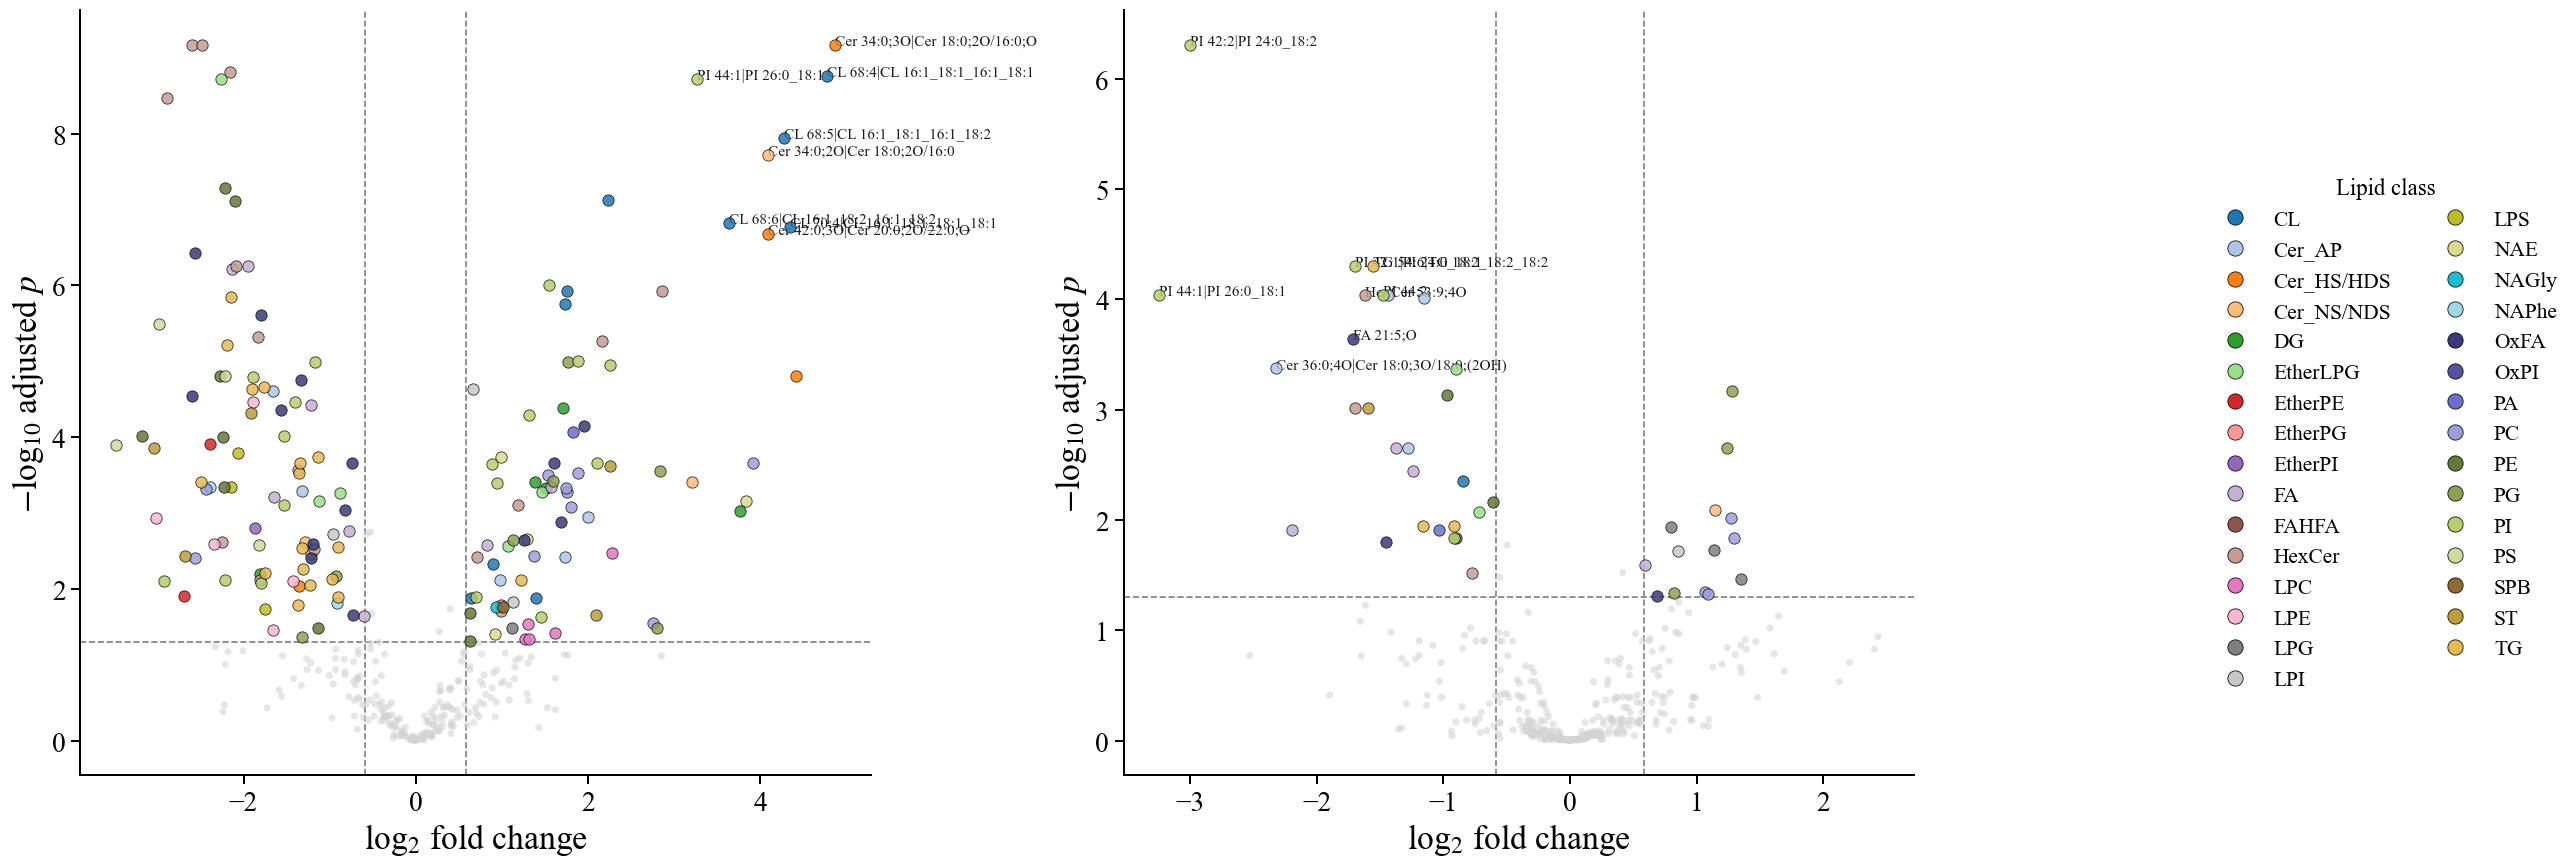


Low vs Ctrl (late)         n_up =  79   n_down =  91
Osc vs Ctrl (late)         n_up =  14   n_down =  28
Late vs Early              n_up = 112   n_down = 105


In [23]:
# A reproducible class color palette
def class_palette(classes):
    n = len(classes)
    # tab20 has 20 distinguishable hues; we have ~35 classes, so combine with tab20b
    cmap = (list(plt.get_cmap("tab20").colors)
            + list(plt.get_cmap("tab20b").colors)
            + list(plt.get_cmap("tab20c").colors))
    return {c: cmap[i % len(cmap)] for i, c in enumerate(classes)}


def build_volcano_table(d, fc_col, padj_col):
    out = d[["lipid_clean", "Ontology", fc_col, padj_col]].dropna().copy()
    out = out.rename(columns={fc_col: "log2FC", padj_col: "padj"})
    out["neglog10_padj"] = -np.log10(out["padj"].replace(0, np.nextafter(0, 1)))
    out["sig"] = (out["padj"] <= ALPHA) & (out["log2FC"].abs() >= FC_THRESHOLD)
    return out


def plot_volcano(ax, vt, palette, label_top_n=10):
    # Non-significant points: gray, small, transparent
    ns = vt[~vt["sig"]]
    ax.scatter(ns["log2FC"], ns["neglog10_padj"],
               s=22, color="lightgray", edgecolor="none", alpha=0.55, zorder=2)

    # Significant points: color by class, larger
    sig = vt[vt["sig"]]
    for cls, sub in sig.groupby("Ontology"):
        ax.scatter(sub["log2FC"], sub["neglog10_padj"],
                   s=55, color=palette.get(cls, "black"),
                   edgecolor="black", linewidth=0.5, alpha=0.85,
                   zorder=4, label=cls)

    # Threshold lines
    ax.axhline(-np.log10(ALPHA), linestyle="--", color="gray", linewidth=1.1, zorder=1)
    ax.axvline( FC_THRESHOLD,  linestyle="--", color="gray", linewidth=1.1, zorder=1)
    ax.axvline(-FC_THRESHOLD,  linestyle="--", color="gray", linewidth=1.1, zorder=1)

    # Label top N species by combined rank (significance + magnitude)
    sig = sig.copy()
    sig["score"] = sig["neglog10_padj"] * sig["log2FC"].abs()
    top = sig.nlargest(label_top_n, "score")
    texts = [ax.text(r["log2FC"], r["neglog10_padj"], r["lipid_clean"],
                     fontsize=10, alpha=0.9)
             for _, r in top.iterrows()]
    try:
        from adjustText import adjust_text
        adjust_text(texts, ax=ax,
                    arrowprops=dict(arrowstyle="-", color="gray", lw=0.6),
                    expand=(1.2, 1.4), force_text=(0.3, 0.4))
    except ImportError:
        pass  # fall back to overlapping labels if adjustText unavailable

    ax.set_xlabel("log$_2$ fold change", fontsize=22)
    ax.set_ylabel("$-$log$_{10}$ adjusted $p$", fontsize=22)


# Gather classes present across the two primary contrasts and assign colors
vt_dict = {k: build_volcano_table(dedup, *CONTRASTS[k][:2]) for k in PRIMARY_CONTRASTS}
all_sig_classes = sorted({c for k in PRIMARY_CONTRASTS for c in vt_dict[k].loc[vt_dict[k]["sig"], "Ontology"].unique()})
palette = class_palette(all_sig_classes)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, key in zip(axes, PRIMARY_CONTRASTS):
    plot_volcano(ax, vt_dict[key], palette, label_top_n=8)

# Right-side legend — one per class shown across both panels
handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=10,
                      markerfacecolor=palette[c], markeredgecolor="black",
                      markeredgewidth=0.5, label=c)
           for c in all_sig_classes]
ncol_legend = 2 if len(handles) > 15 else 1
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5),
           ncol=ncol_legend, fontsize=14, title="Lipid class", title_fontsize=15)

fig.tight_layout(rect=[0, 0, 0.93 if ncol_legend == 1 else 0.88, 1])
# fig.savefig("fig1_volcano.pdf")
plt.show()

# Print summary counts
print()
for key in PRIMARY_CONTRASTS:
    vt = vt_dict[key]
    n_up = ((vt["sig"]) & (vt["log2FC"] > 0)).sum()
    n_dn = ((vt["sig"]) & (vt["log2FC"] < 0)).sum()
    print(f"{CONTRASTS[key][2]:25s}  n_up = {n_up:3d}   n_down = {n_dn:3d}")

## Figure 2 — Class-level differential summary

For each lipid class: how many species went up and how many went down (significantly)
in each contrast. Up bars point right, down bars point left.

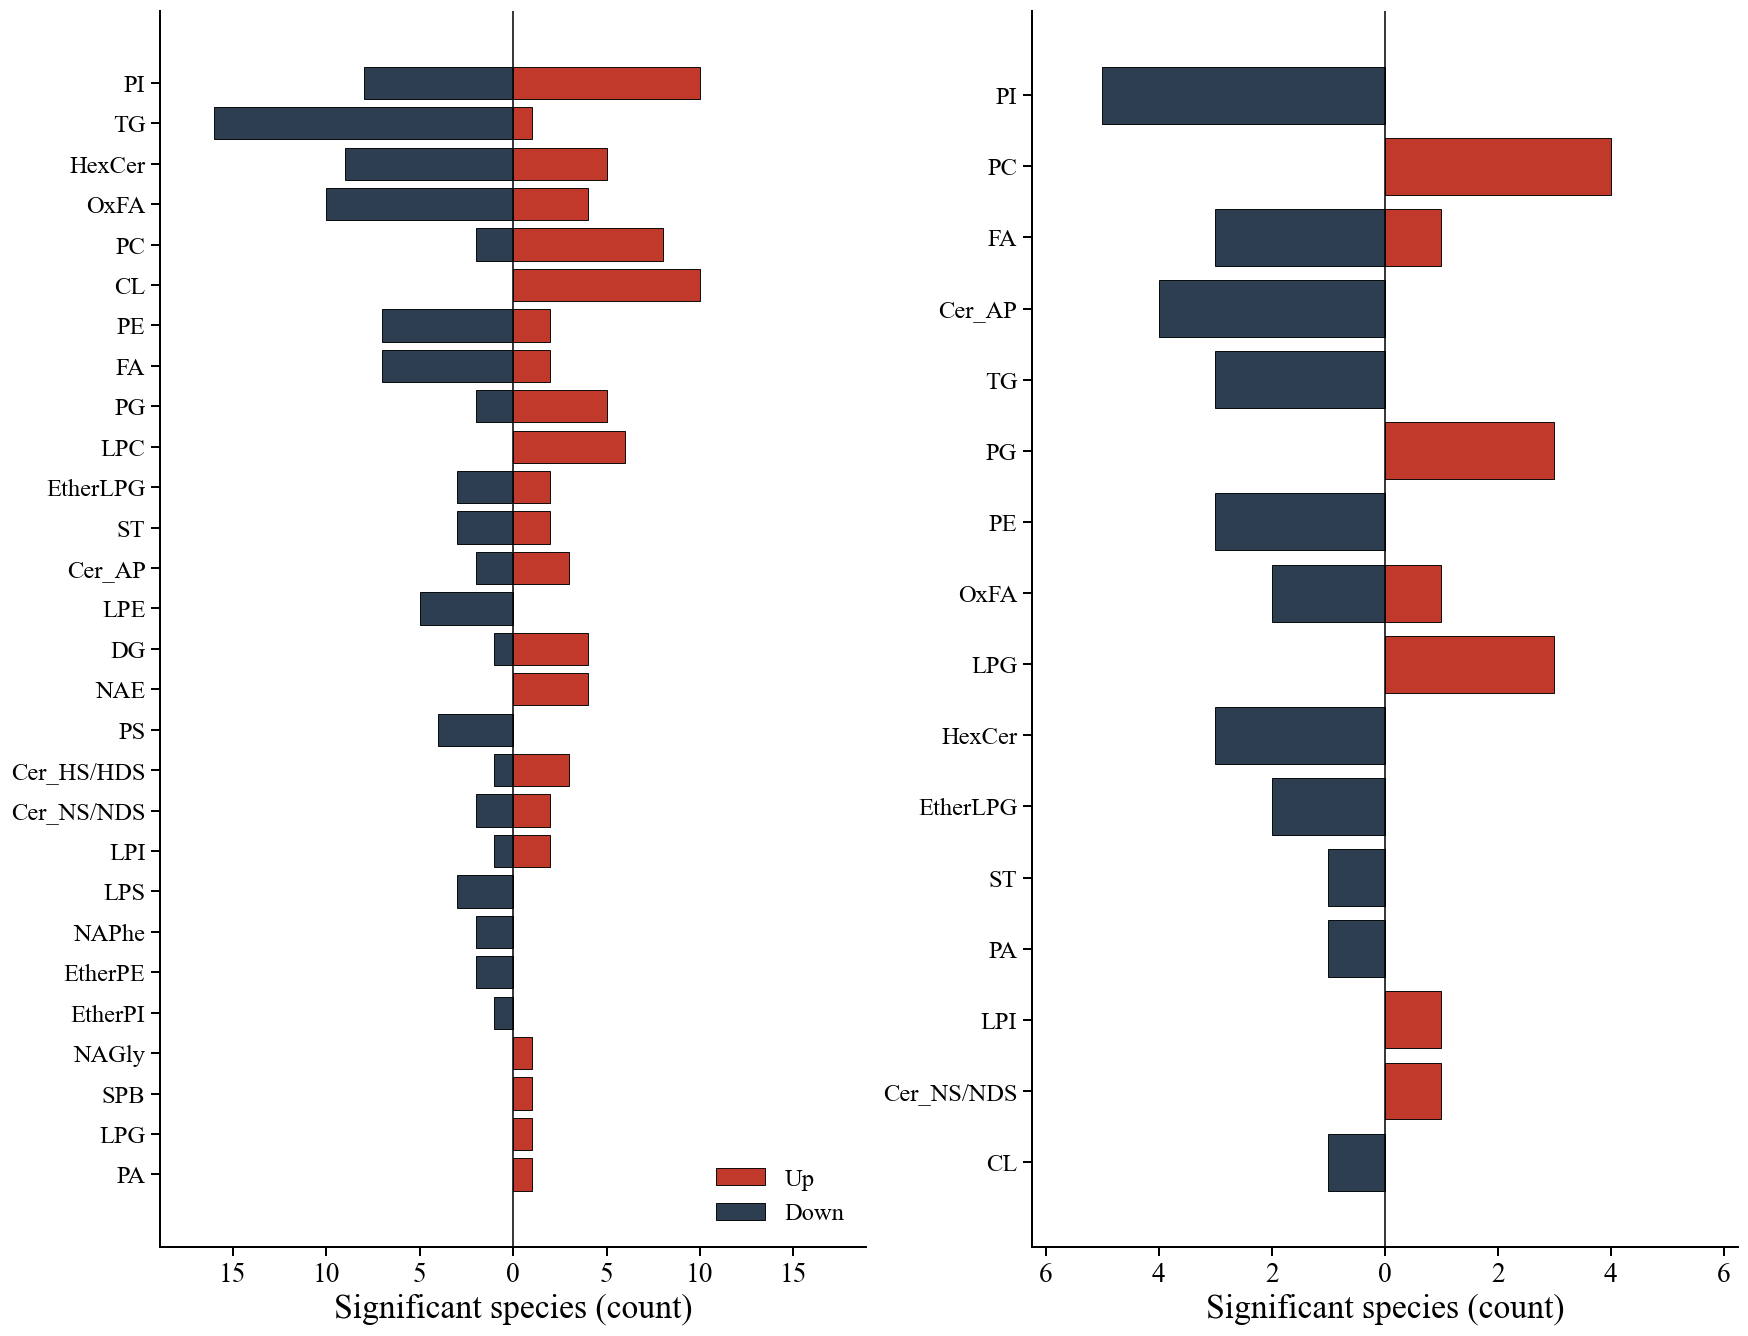

In [24]:
def class_counts(vt):
    """Up / down counts per Ontology, restricted to significant species."""
    sig = vt[vt["sig"]].copy()
    sig["dir"] = np.where(sig["log2FC"] > 0, "up", "down")
    counts = (sig.groupby(["Ontology", "dir"]).size().unstack(fill_value=0)
                 .reindex(columns=["up", "down"], fill_value=0))
    counts["total"] = counts["up"] + counts["down"]
    return counts.sort_values("total", ascending=True)


def plot_class_bars(ax, counts, title=""):
    y = np.arange(len(counts))
    ax.barh(y, counts["up"],  color="#c0392b", edgecolor="black", linewidth=0.6, label="Up")
    ax.barh(y, -counts["down"], color="#2c3e50", edgecolor="black", linewidth=0.6, label="Down")
    ax.set_yticks(y)
    ax.set_yticklabels(counts.index, fontsize=16)
    ax.axvline(0, color="black", linewidth=1.0)
    ax.set_xlabel("Significant species (count)", fontsize=22)
    # if title:
    #     ax.text(0.02, 0.98, title, transform=ax.transAxes, va="top",
    #             fontsize=18, fontweight="bold")
    # Symmetric x range
    mx = max(counts["up"].max(), counts["down"].max())
    ax.set_xlim(-mx * 1.15 - 0.5, mx * 1.15 + 0.5)
    # Use a formatter so labels stay correct even if matplotlib re-picks tick locations
    from matplotlib.ticker import FuncFormatter
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(abs(round(x)))}"))


fig, axes = plt.subplots(1, 2, figsize=(16, max(8, 0.35 * dedup["Ontology"].nunique())))
for ax, key in zip(axes, PRIMARY_CONTRASTS):
    counts = class_counts(vt_dict[key])
    plot_class_bars(ax, counts, title=CONTRASTS[key][2])
axes[0].legend(loc="lower right", fontsize=16)

fig.tight_layout()
# fig.savefig("fig2_class_summary.pdf")
plt.show()

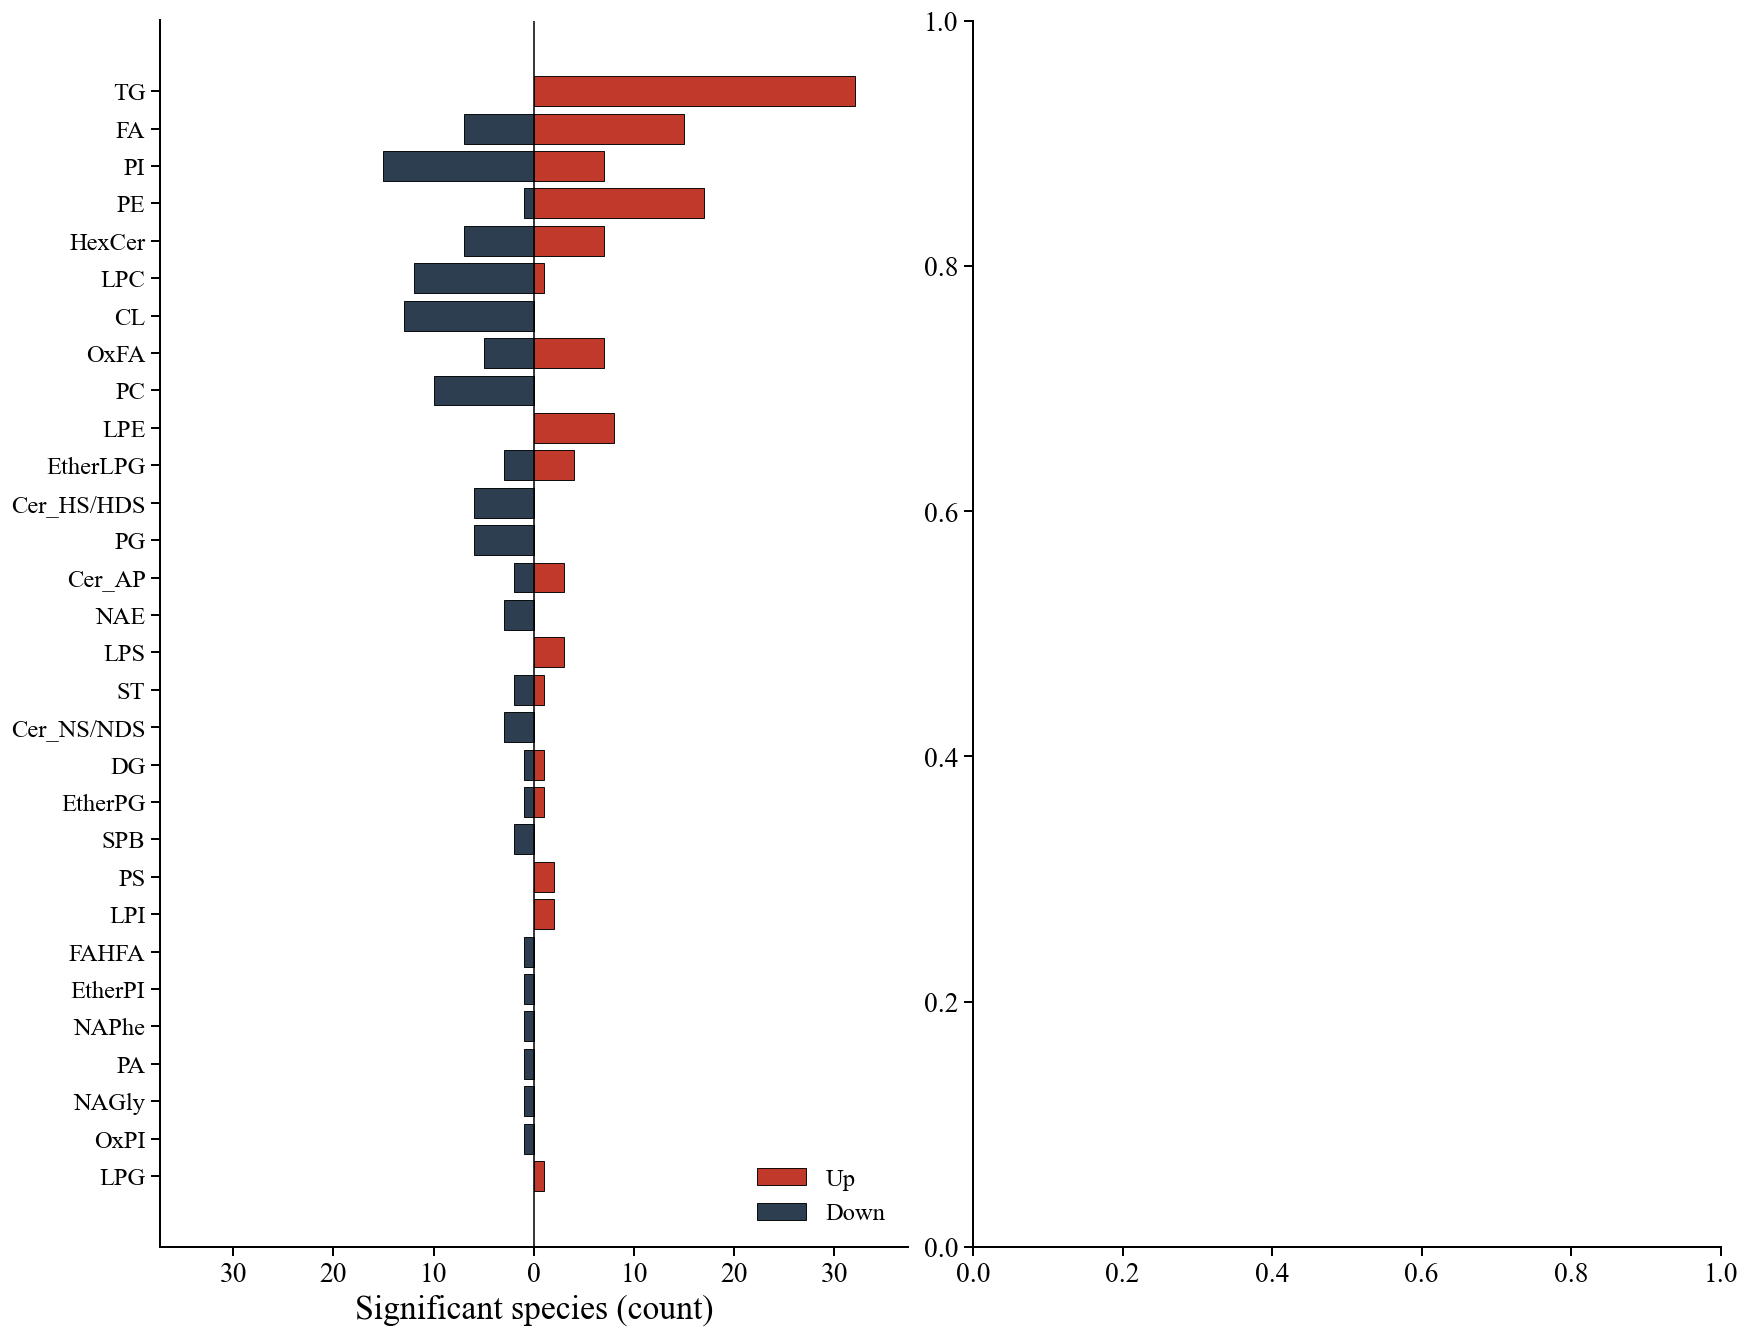

In [25]:
def class_counts(vt):
    """Up / down counts per Ontology, restricted to significant species."""
    sig = vt[vt["sig"]].copy()
    sig["dir"] = np.where(sig["log2FC"] > 0, "up", "down")
    counts = (sig.groupby(["Ontology", "dir"]).size().unstack(fill_value=0)
                 .reindex(columns=["up", "down"], fill_value=0))
    counts["total"] = counts["up"] + counts["down"]
    return counts.sort_values("total", ascending=True)


def plot_class_bars(ax, counts, title=""):
    y = np.arange(len(counts))
    ax.barh(y, counts["up"],  color="#c0392b", edgecolor="black", linewidth=0.6, label="Up")
    ax.barh(y, -counts["down"], color="#2c3e50", edgecolor="black", linewidth=0.6, label="Down")
    ax.set_yticks(y)
    ax.set_yticklabels(counts.index, fontsize=16)
    ax.axvline(0, color="black", linewidth=1.0)
    ax.set_xlabel("Significant species (count)", fontsize=22)
    # if title:
    #     ax.text(0.02, 0.98, title, transform=ax.transAxes, va="top",
    #             fontsize=18, fontweight="bold")
    # Symmetric x range
    mx = max(counts["up"].max(), counts["down"].max())
    ax.set_xlim(-mx * 1.15 - 0.5, mx * 1.15 + 0.5)
    # Use a formatter so labels stay correct even if matplotlib re-picks tick locations
    from matplotlib.ticker import FuncFormatter
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(abs(round(x)))}"))


fig, axes = plt.subplots(1, 2, figsize=(16, max(8, 0.35 * dedup["Ontology"].nunique())))
for ax, key in zip(axes, Ctrl_Contrasts):
    counts = class_counts(vt_dict[key])
    plot_class_bars(ax, counts, title=CONTRASTS[key][2])
axes[0].legend(loc="lower right", fontsize=16)

fig.tight_layout()
fig.savefig("fig2_class_summary_late_early.pdf")
plt.show()

In [26]:
PRIMARY_CONTRASTS

['low_late', 'osc_late', 'late_early']

## Figure 3 — Class heatmap across all timepoints

Mean log2FC per ontology class for every available stress-vs-control comparison
(per-timepoint and combined). Red = up under stress, blue = down. Cells with too few
species (< 2) are masked so the colors aren't dominated by single-species classes.

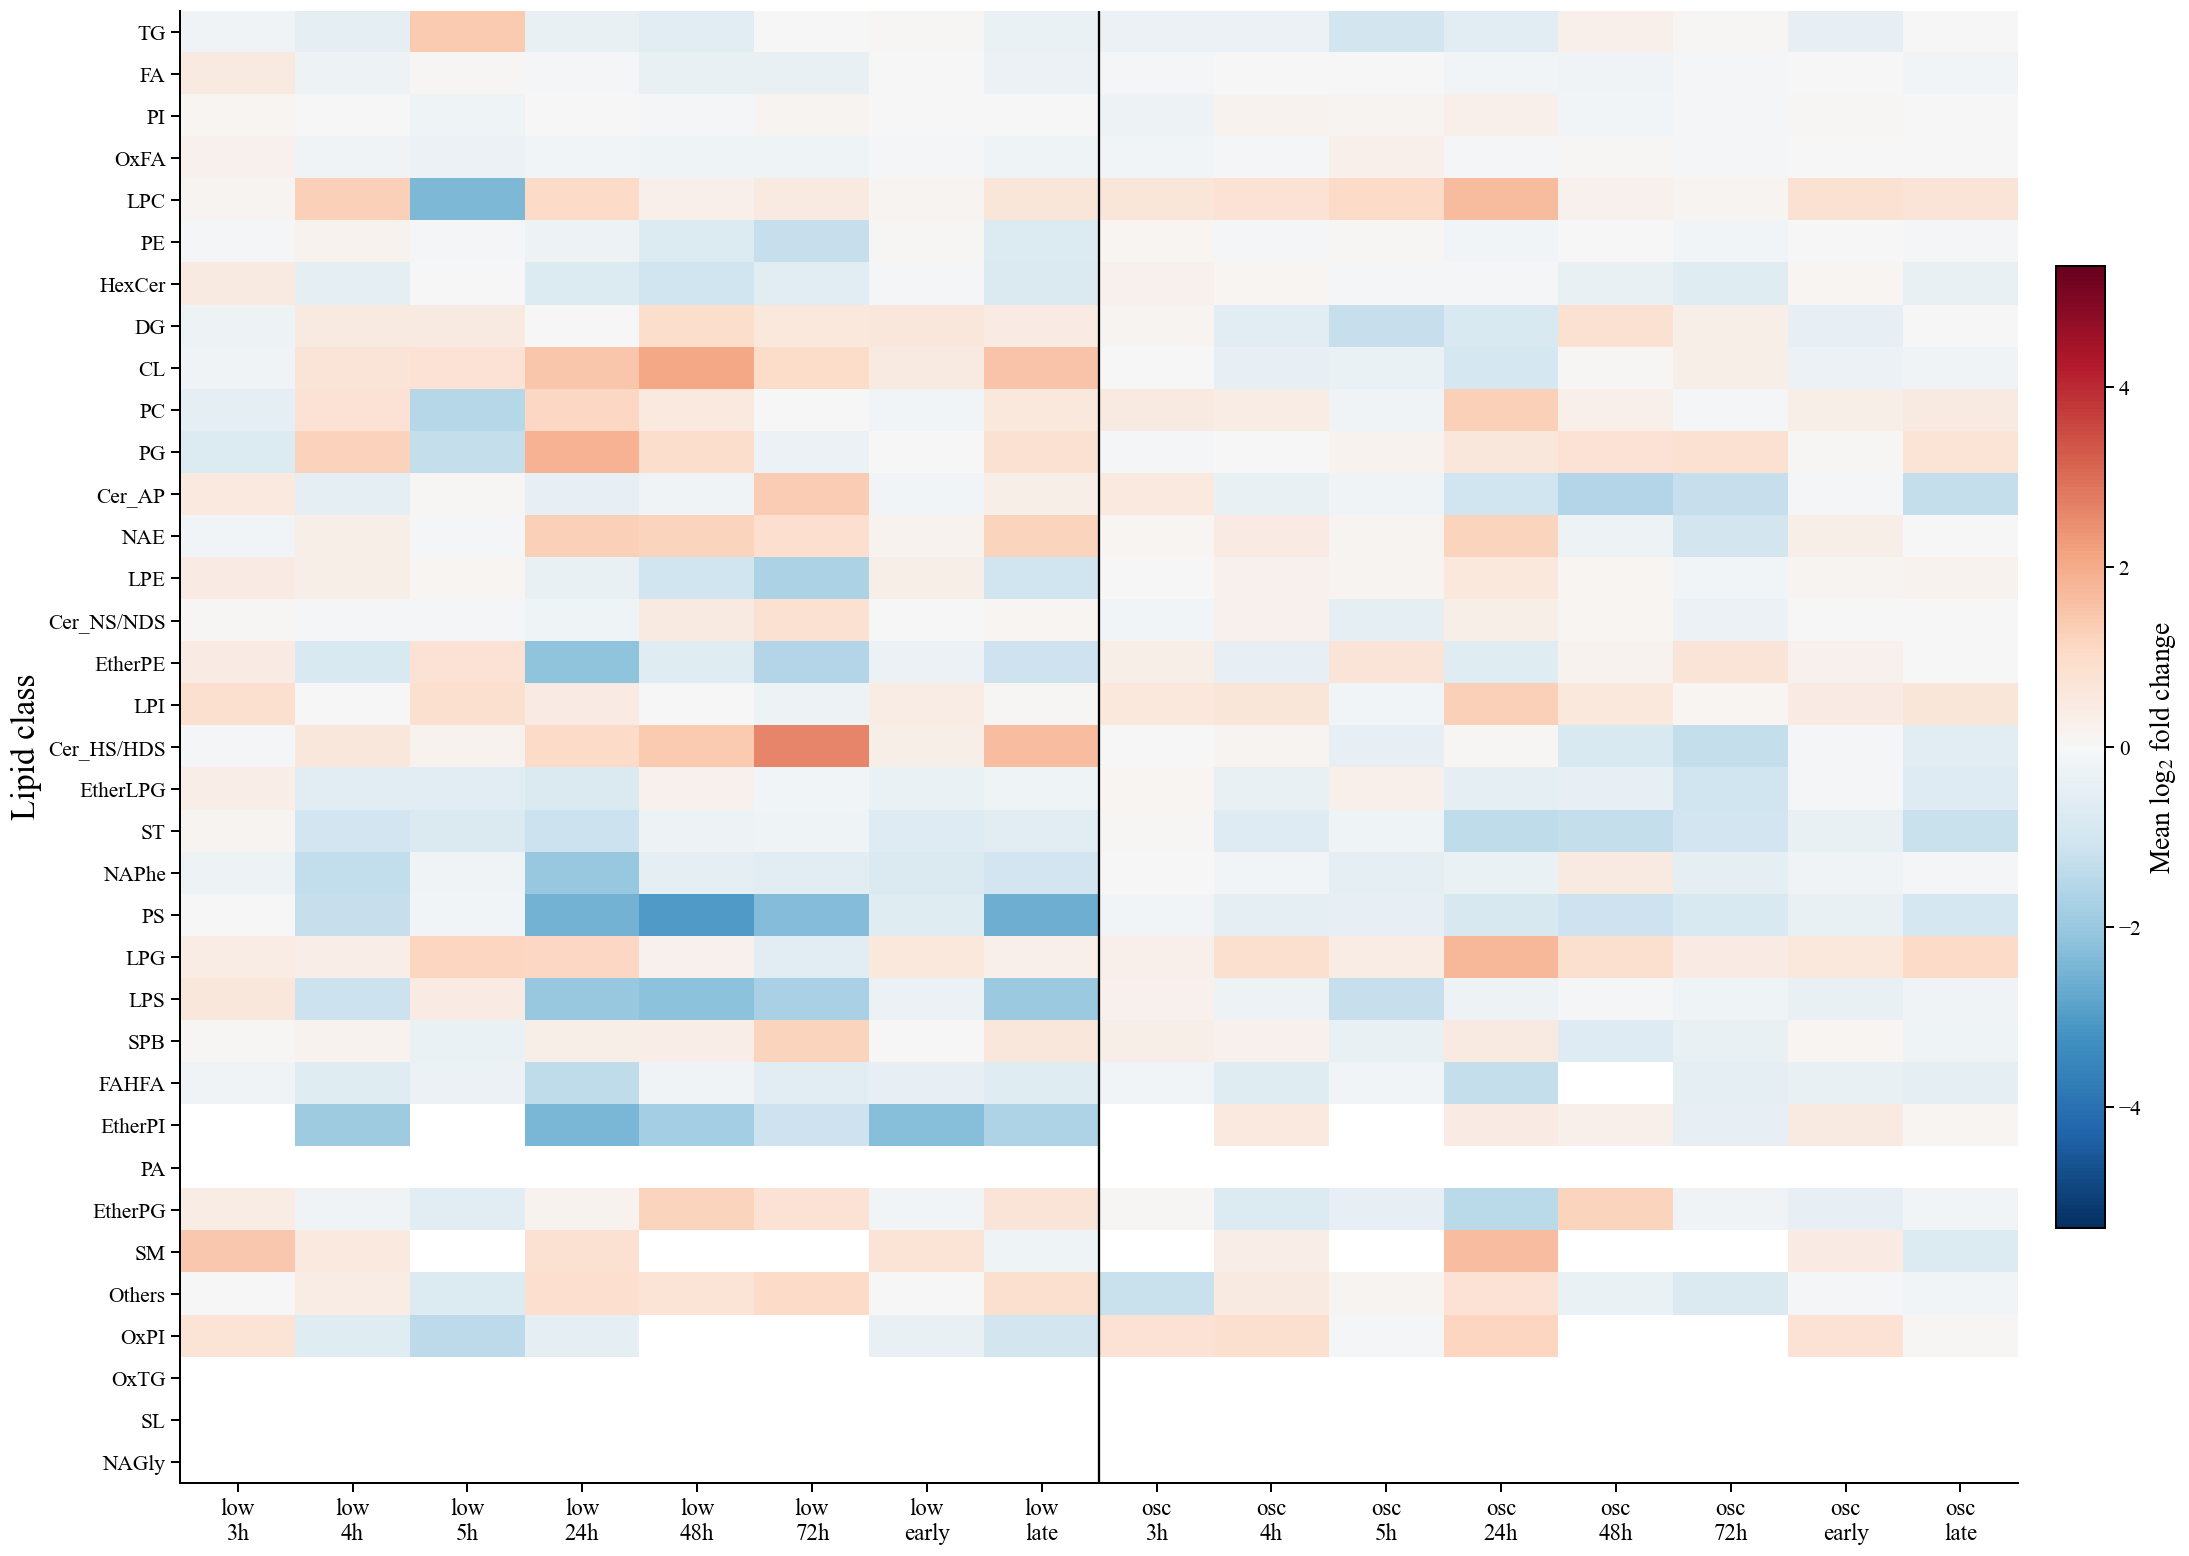

In [27]:
# Pull every comparison column of the form "<X>/control_<Y>" with its log2FC and padj
TIMEPOINT_ORDER = ["3", "4", "5", "24", "48", "72", "early_combined", "late_combined"]
heat_cols = []  # list of (label, fc_col, padj_col)
for stress in ("low", "osc"):
    for t in TIMEPOINT_ORDER:
        fc   = f"{stress}/control_{t}"
        padj = f"{stress}/control_{t}_ANOVA_padj"
        if fc in df.columns and padj in df.columns:
            short = "early" if t == "early_combined" else "late" if t == "late_combined" else f"{t}h"
            heat_cols.append((f"{stress}\n{short}", fc, padj))

# Compute mean log2FC per Ontology × contrast (using deduped table)
classes_ordered = (dedup["Ontology"].value_counts().index.tolist())  # most populous first
heat = pd.DataFrame(index=classes_ordered, columns=[c[0] for c in heat_cols], dtype=float)
counts = heat.copy()

for label, fc_col, _ in heat_cols:
    g = dedup.groupby("Ontology")[fc_col].agg(["mean", "count"])
    heat[label]   = g["mean"]
    counts[label] = g["count"]

# Mask classes with fewer than 2 species
mask_small = counts < 2

# Heatmap
fig_w = 1.0 * len(heat.columns) + 4
fig_h = 0.35 * len(heat.index) + 2
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

vmax = np.nanmax(np.abs(heat.values))
im = ax.imshow(heat.where(~mask_small).values, aspect="auto",
               cmap="RdBu_r", vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, fontsize=15)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Lipid class", fontsize=22)

# Separator between low and osc halves
half = sum(1 for c in heat.columns if c.startswith("low"))
ax.axvline(half - 0.5, color="black", linewidth=1.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Mean log$_2$ fold change", fontsize=18)
cbar.ax.tick_params(labelsize=14)

fig.tight_layout()
fig.savefig("fig3_class_heatmap.pdf")
plt.show()

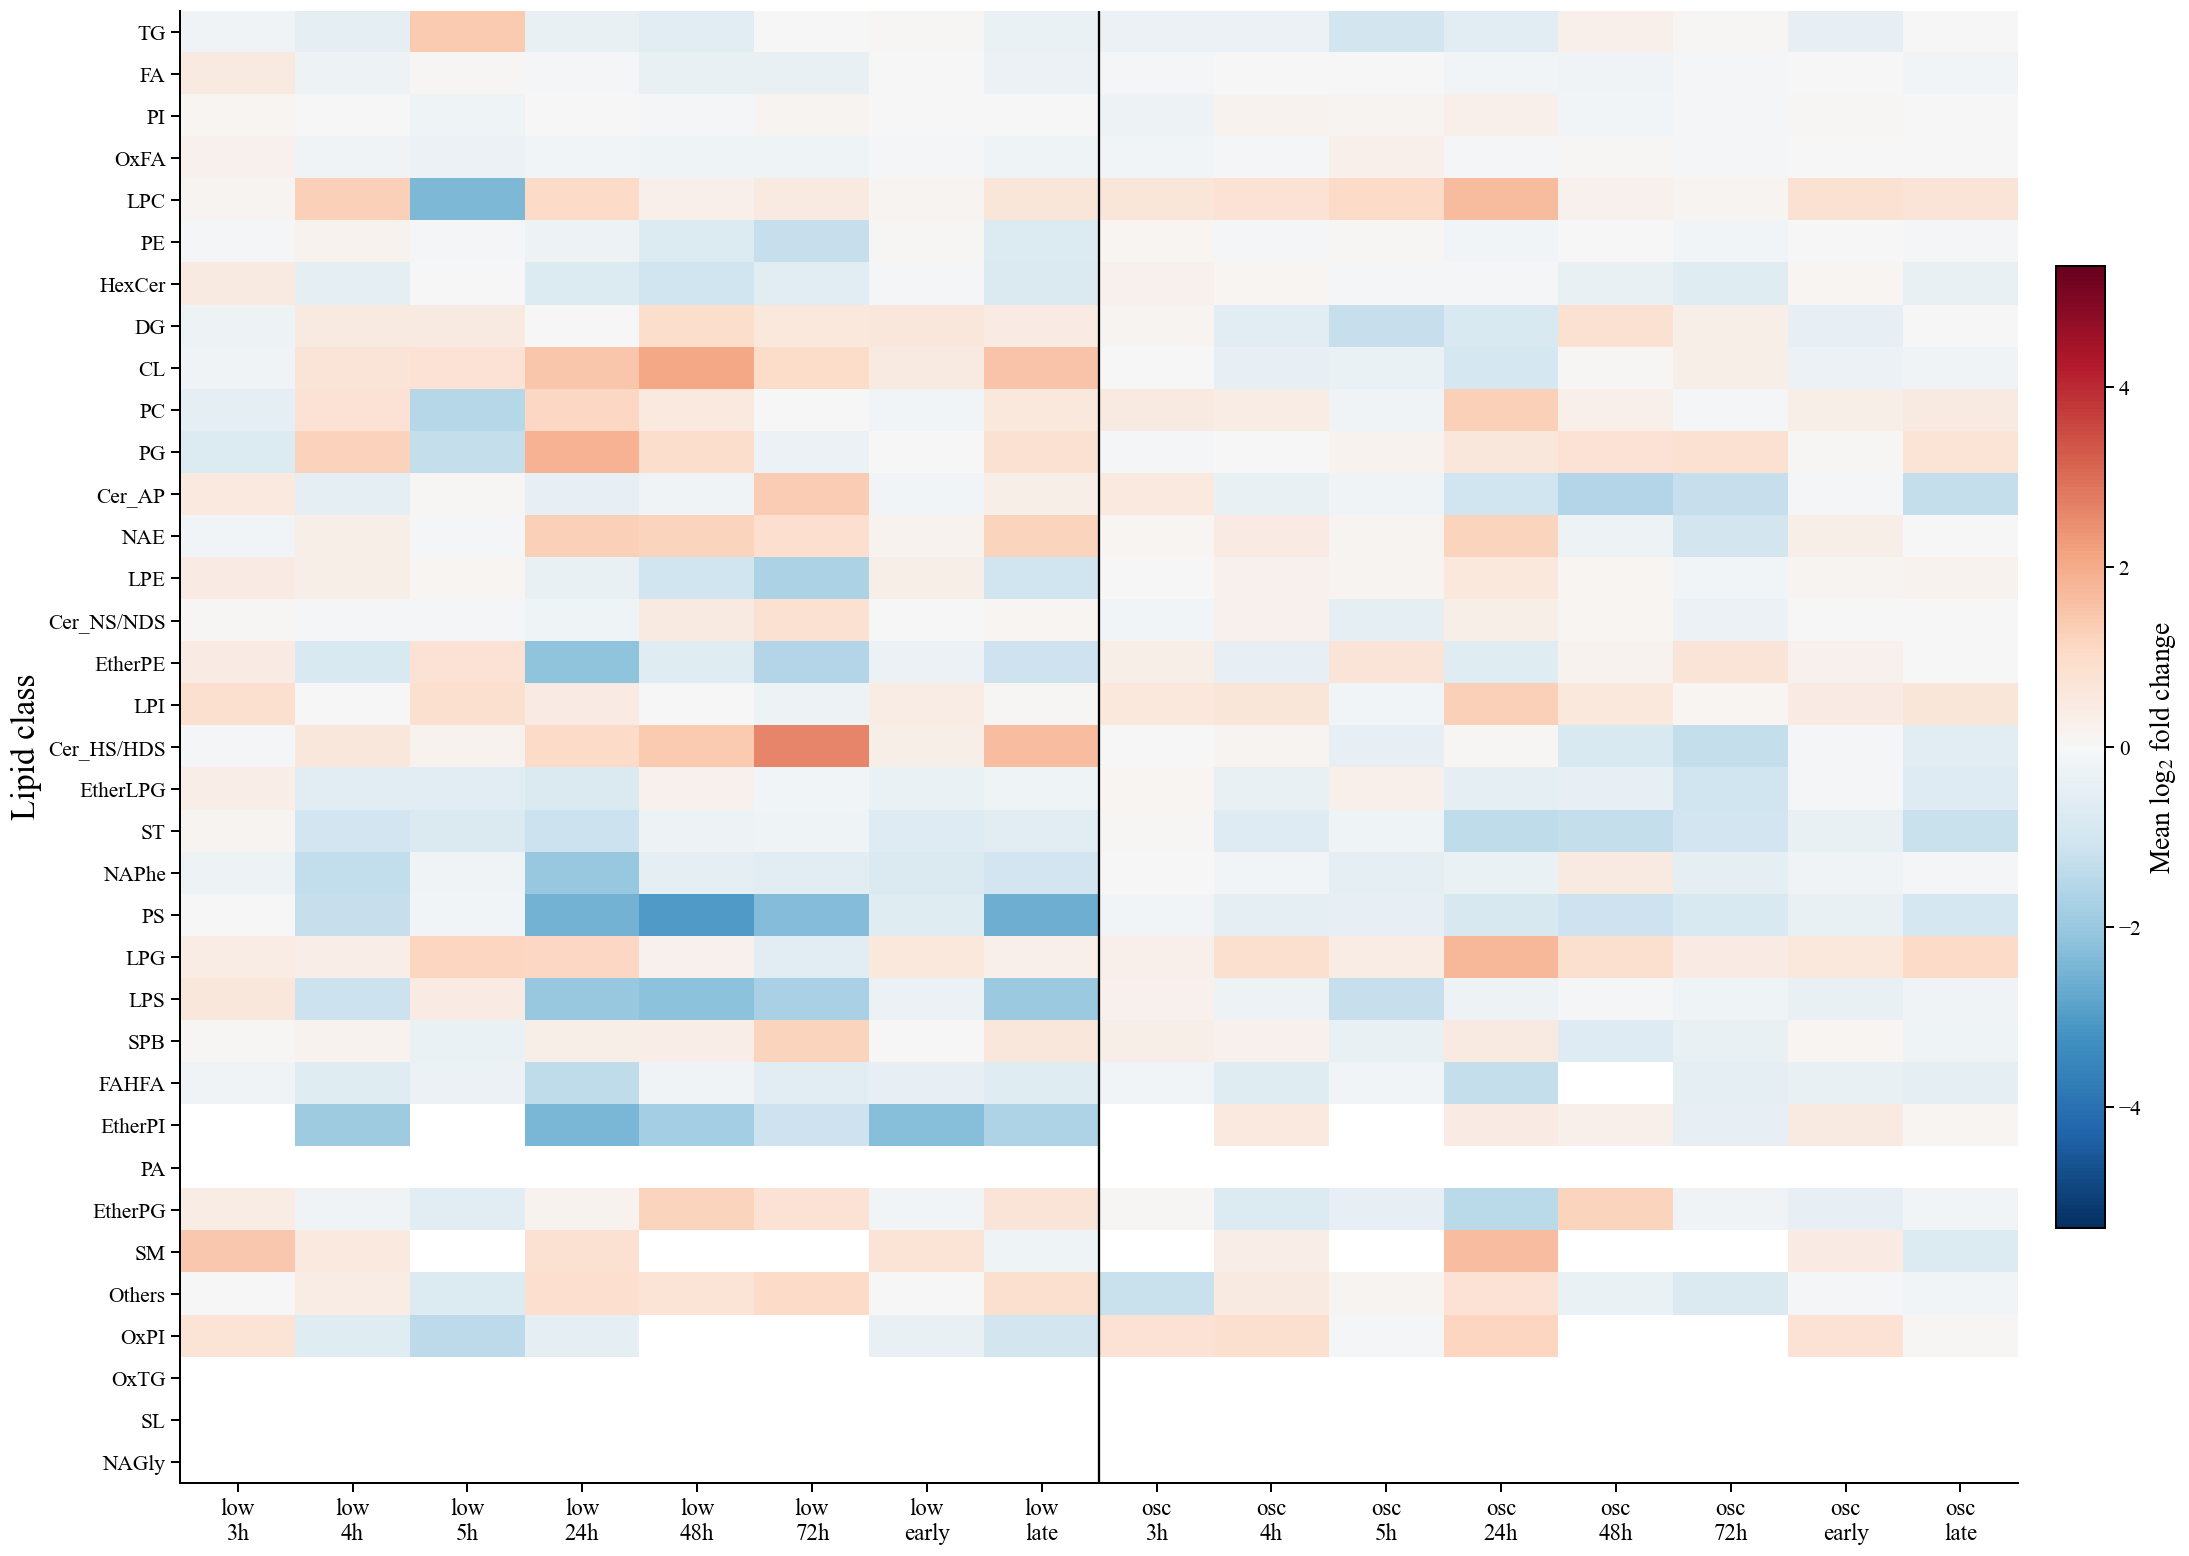

In [28]:
# Pull every comparison column of the form "<X>/control_<Y>" with its log2FC and padj
TIMEPOINT_ORDER = ["3", "4", "5", "24", "48", "72", "early_combined", "late_combined"]
heat_cols = []  # list of (label, fc_col, padj_col)
for stress in ("low", "osc"):
    for t in TIMEPOINT_ORDER:
        fc   = f"{stress}/control_{t}"
        padj = f"{stress}/control_{t}_ANOVA_padj"
        if fc in df.columns and padj in df.columns:
            short = "early" if t == "early_combined" else "late" if t == "late_combined" else f"{t}h"
            heat_cols.append((f"{stress}\n{short}", fc, padj))

# Compute mean log2FC per Ontology × contrast (using deduped table)
classes_ordered = (dedup["Ontology"].value_counts().index.tolist())  # most populous first
heat = pd.DataFrame(index=classes_ordered, columns=[c[0] for c in heat_cols], dtype=float)
counts = heat.copy()

for label, fc_col, _ in heat_cols:
    g = dedup.groupby("Ontology")[fc_col].agg(["mean", "count"])
    heat[label]   = g["mean"]
    counts[label] = g["count"]

# Mask classes with fewer than 2 species
mask_small = counts < 2

# Heatmap
fig_w = 1.0 * len(heat.columns) + 4
fig_h = 0.35 * len(heat.index) + 2
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

vmax = np.nanmax(np.abs(heat.values))
im = ax.imshow(heat.where(~mask_small).values, aspect="auto",
               cmap="RdBu_r", vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, fontsize=15)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Lipid class", fontsize=22)

# Separator between low and osc halves
half = sum(1 for c in heat.columns if c.startswith("low"))
ax.axvline(half - 0.5, color="black", linewidth=1.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Mean log$_2$ fold change", fontsize=18)
cbar.ax.tick_params(labelsize=14)

fig.tight_layout()
# fig.savefig("fig3_class_heatmap.pdf")
plt.show()

## Figure 4 — Top species per contrast

Top 15 up- and top 15 down-regulated species (by absolute log2FC, among significant)
for each primary contrast. Useful for "which specific lipids are driving the response."

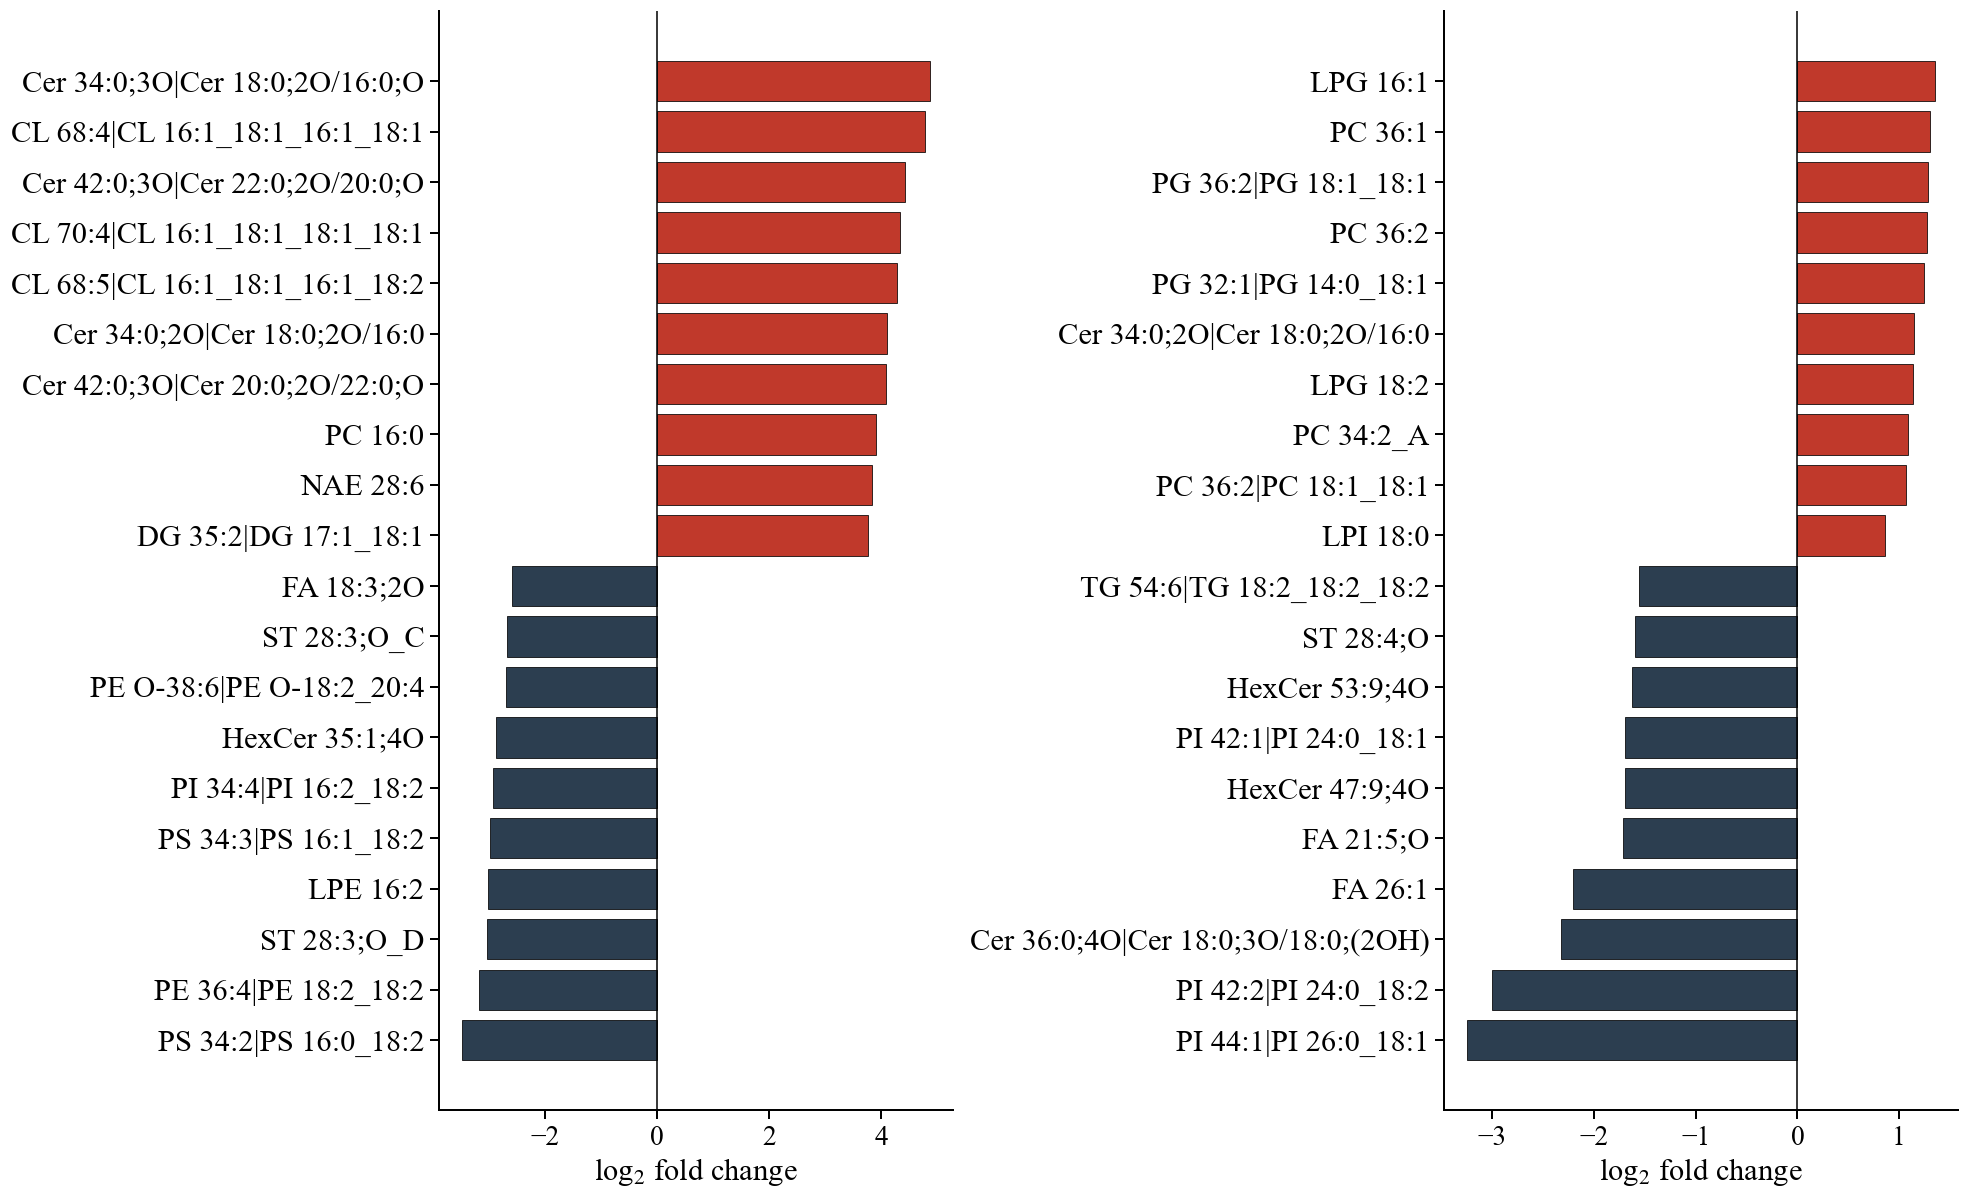

In [29]:
def plot_top_species(ax, vt, n=15):
    sig = vt[vt["sig"]].copy()
    top_up   = sig[sig["log2FC"] > 0].nlargest(n, "log2FC")
    top_down = sig[sig["log2FC"] < 0].nsmallest(n, "log2FC")
    top = pd.concat([top_down, top_up]).sort_values("log2FC")

    colors = ["#2c3e50" if x < 0 else "#c0392b" for x in top["log2FC"]]
    y = np.arange(len(top))
    ax.barh(y, top["log2FC"], color=colors, edgecolor="black", linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(top["lipid_clean"], fontsize=20)
    ax.axvline(0, color="black", linewidth=1.0)
    ax.set_xlabel("log$_2$ fold change", fontsize=20)


fig, axes = plt.subplots(1, 2, figsize=(18, 11))
for ax, key in zip(axes, PRIMARY_CONTRASTS):
    plot_top_species(ax, vt_dict[key], n=10)
    # ax.text(0.02, 1.02, CONTRASTS[key][2], transform=ax.transAxes,
    #         fontsize=18, fontweight="bold")

fig.tight_layout()
fig.savefig("fig4_top_species.pdf")
plt.show()

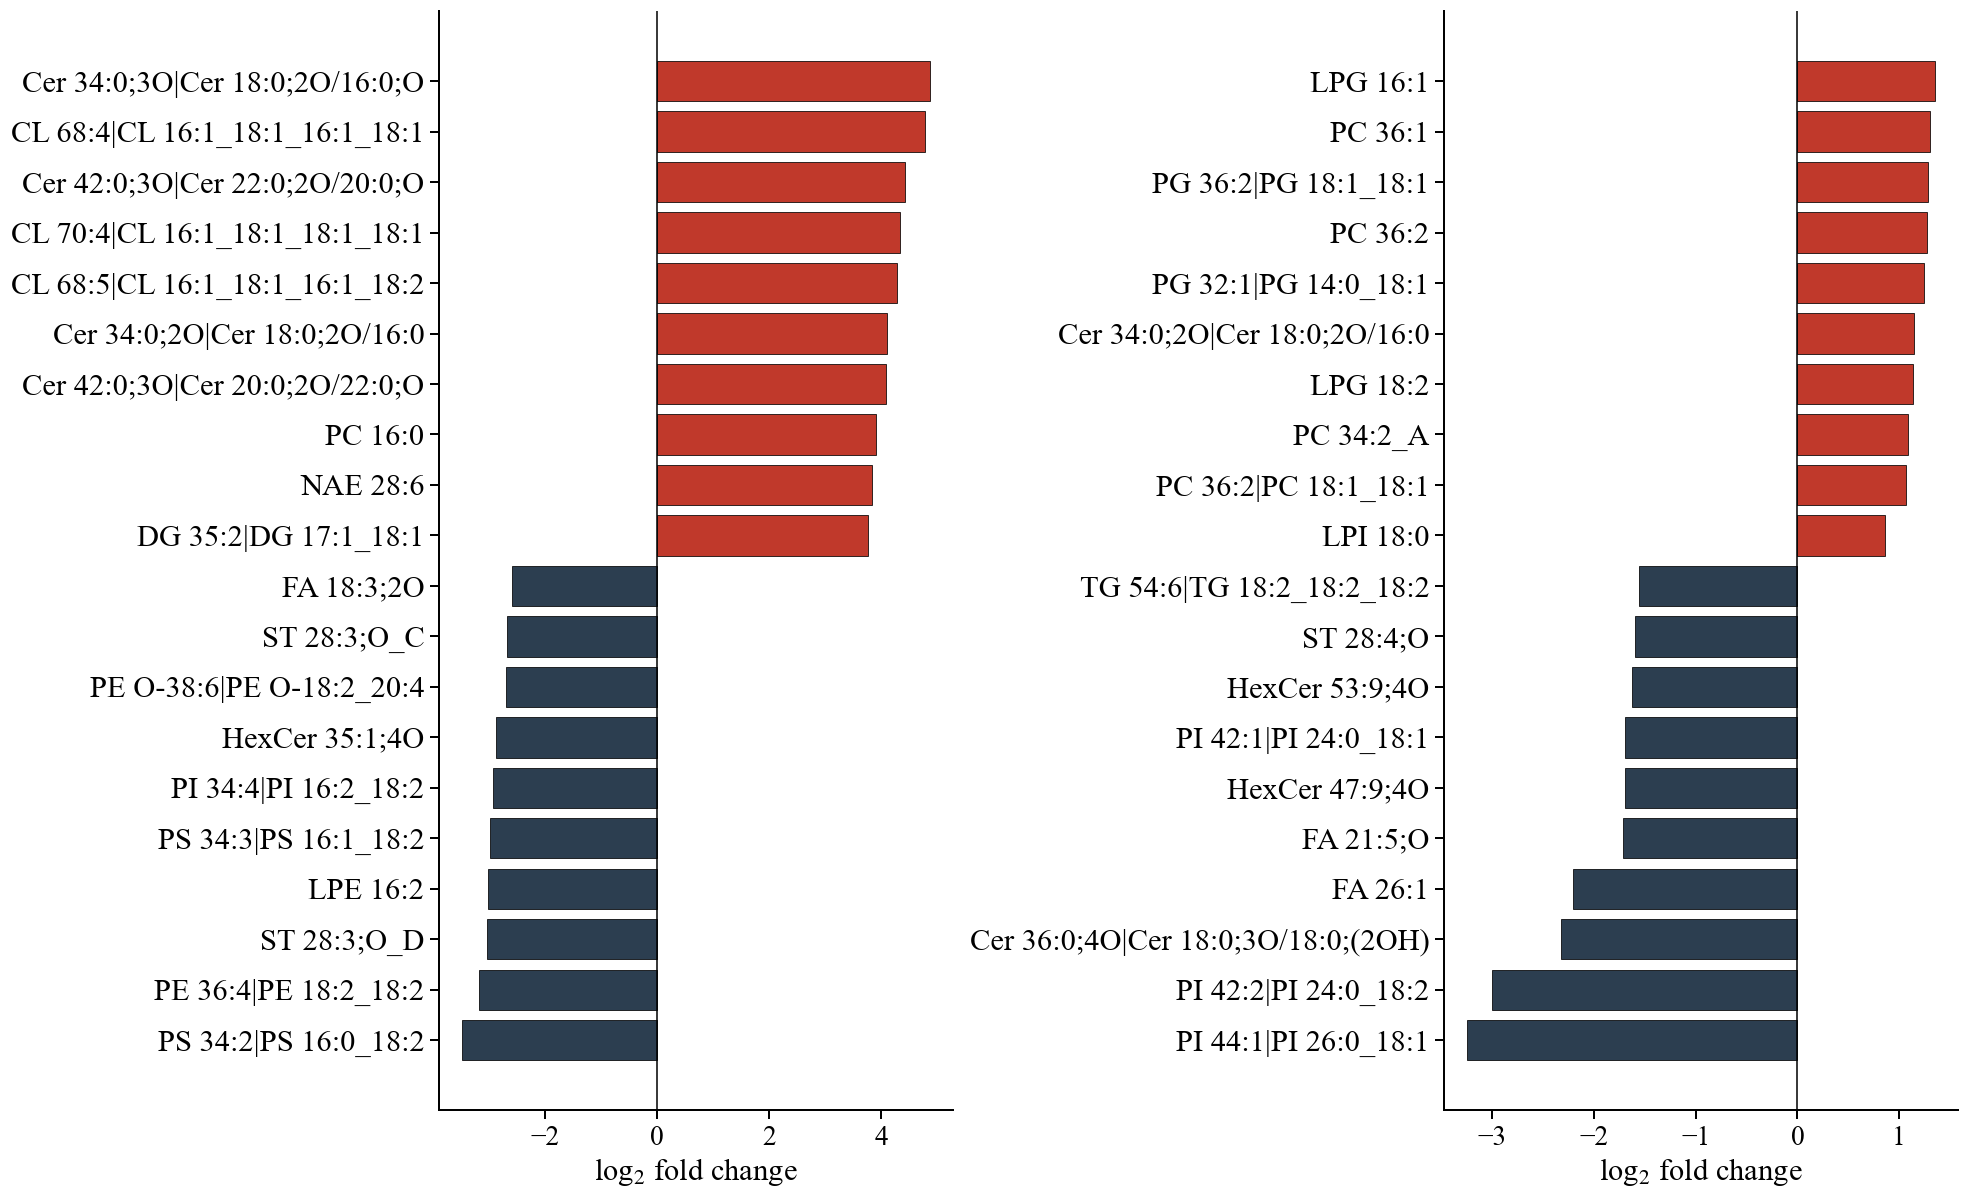

In [30]:
def plot_top_species(ax, vt, n=15):
    sig = vt[vt["sig"]].copy()
    top_up   = sig[sig["log2FC"] > 0].nlargest(n, "log2FC")
    top_down = sig[sig["log2FC"] < 0].nsmallest(n, "log2FC")
    top = pd.concat([top_down, top_up]).sort_values("log2FC")

    colors = ["#2c3e50" if x < 0 else "#c0392b" for x in top["log2FC"]]
    y = np.arange(len(top))
    ax.barh(y, top["log2FC"], color=colors, edgecolor="black", linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(top["lipid_clean"], fontsize=20)
    ax.axvline(0, color="black", linewidth=1.0)
    ax.set_xlabel("log$_2$ fold change", fontsize=20)


fig, axes = plt.subplots(1, 2, figsize=(18, 11))
for ax, key in zip(axes, PRIMARY_CONTRASTS):
    plot_top_species(ax, vt_dict[key], n=10)
    # ax.text(0.02, 1.02, CONTRASTS[key][2], transform=ax.transAxes,
    #         fontsize=18, fontweight="bold")

fig.tight_layout()
fig.savefig("fig4_top_species.pdf")
plt.show()

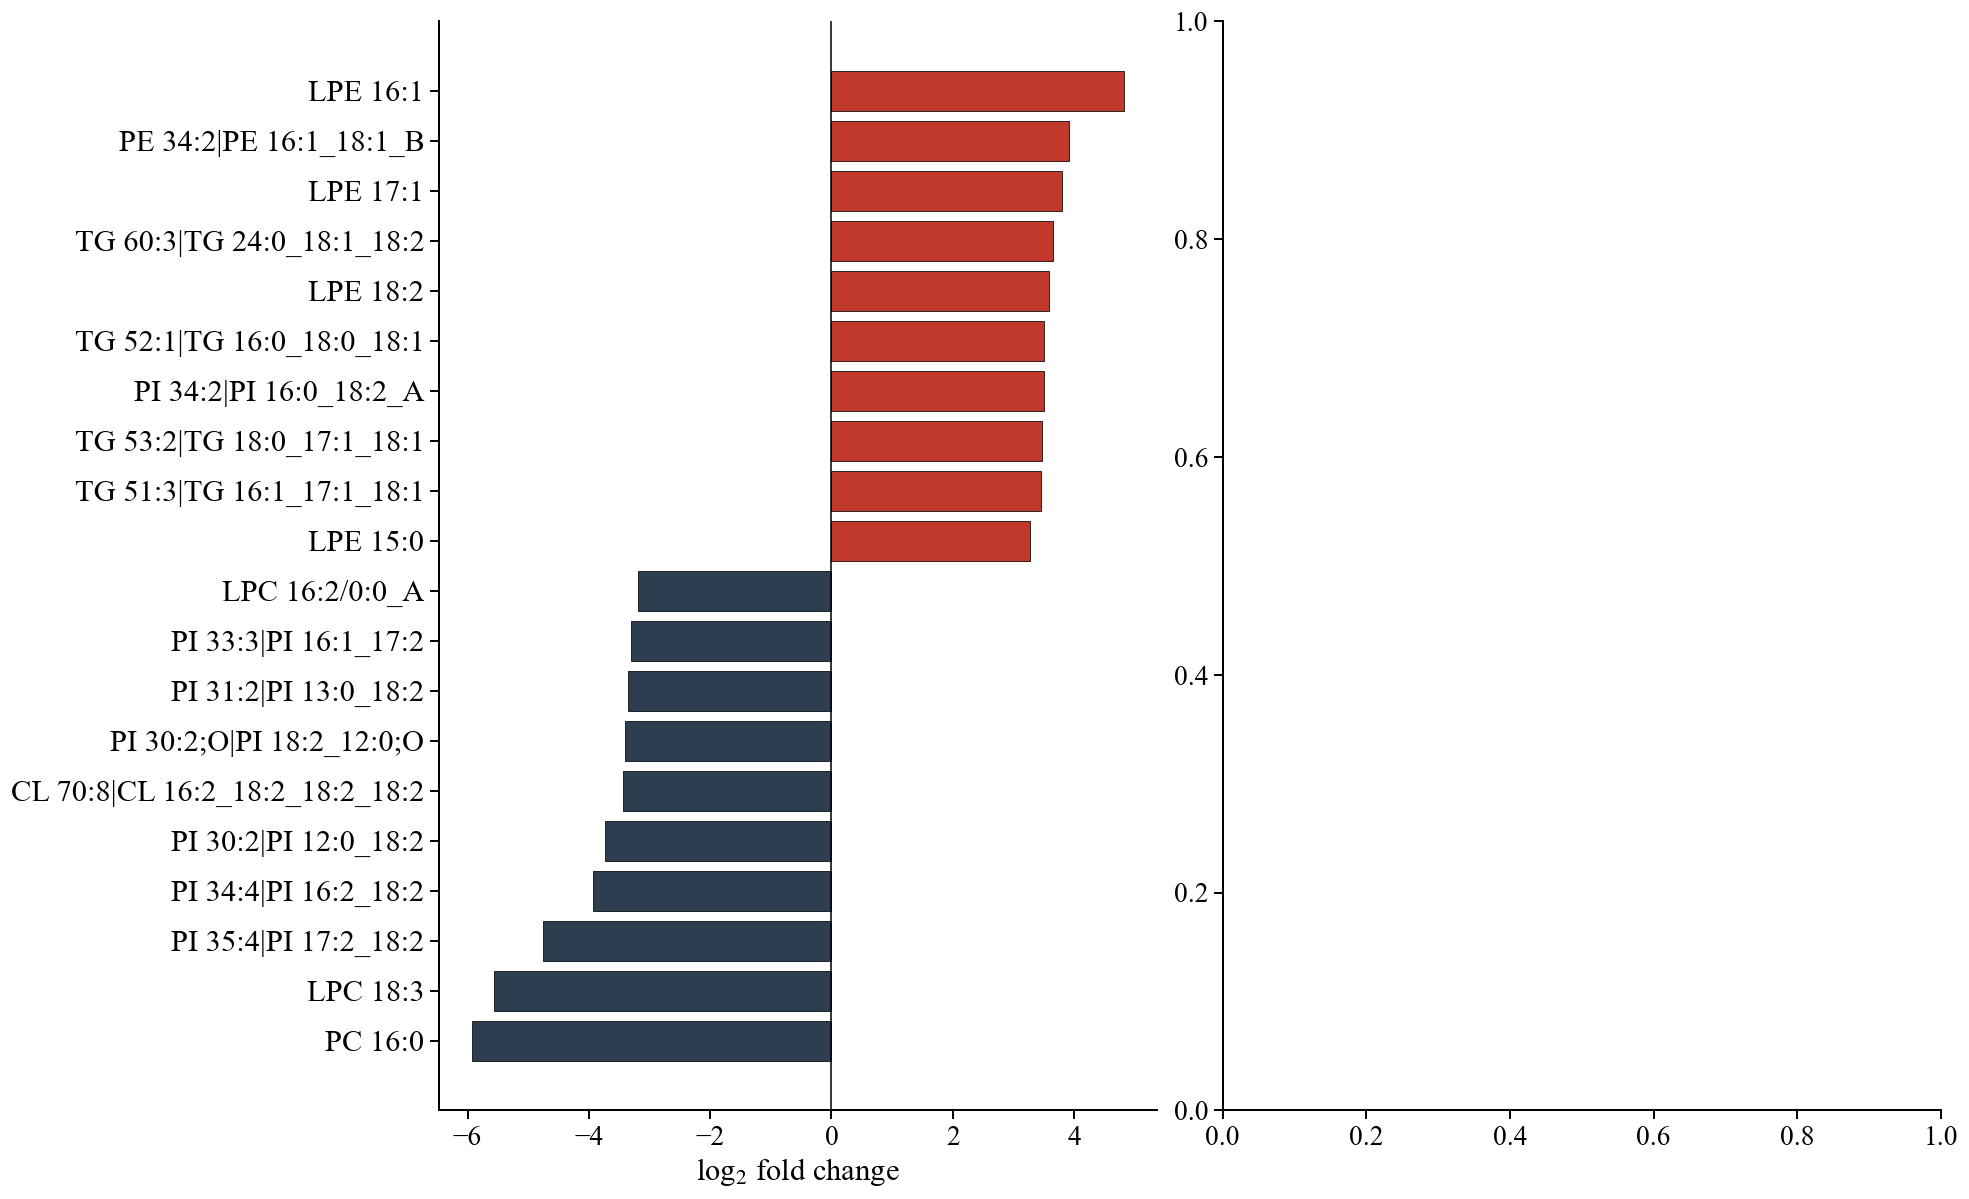

In [31]:
def plot_top_species(ax, vt, n=15):
    sig = vt[vt["sig"]].copy()
    top_up   = sig[sig["log2FC"] > 0].nlargest(n, "log2FC")
    top_down = sig[sig["log2FC"] < 0].nsmallest(n, "log2FC")
    top = pd.concat([top_down, top_up]).sort_values("log2FC")

    colors = ["#2c3e50" if x < 0 else "#c0392b" for x in top["log2FC"]]
    y = np.arange(len(top))
    ax.barh(y, top["log2FC"], color=colors, edgecolor="black", linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(top["lipid_clean"], fontsize=20)
    ax.axvline(0, color="black", linewidth=1.0)
    ax.set_xlabel("log$_2$ fold change", fontsize=20)


fig, axes = plt.subplots(1, 2, figsize=(18, 11))
for ax, key in zip(axes, Ctrl_Contrasts):
    plot_top_species(ax, vt_dict[key], n=10)
    # ax.text(0.02, 1.02, CONTRASTS[key][2], transform=ax.transAxes,
    #         fontsize=18, fontweight="bold")

fig.tight_layout()
fig.savefig("fig4_top_species_late_early.pdf")
plt.show()

## Figure 5 — Class bubble plot

Each bubble is one lipid class for one contrast. Position on x = mean log2FC of the
significant species in that class; size = number of significant species. Lets you see
which classes are systematically up/down and how dominant the response is.

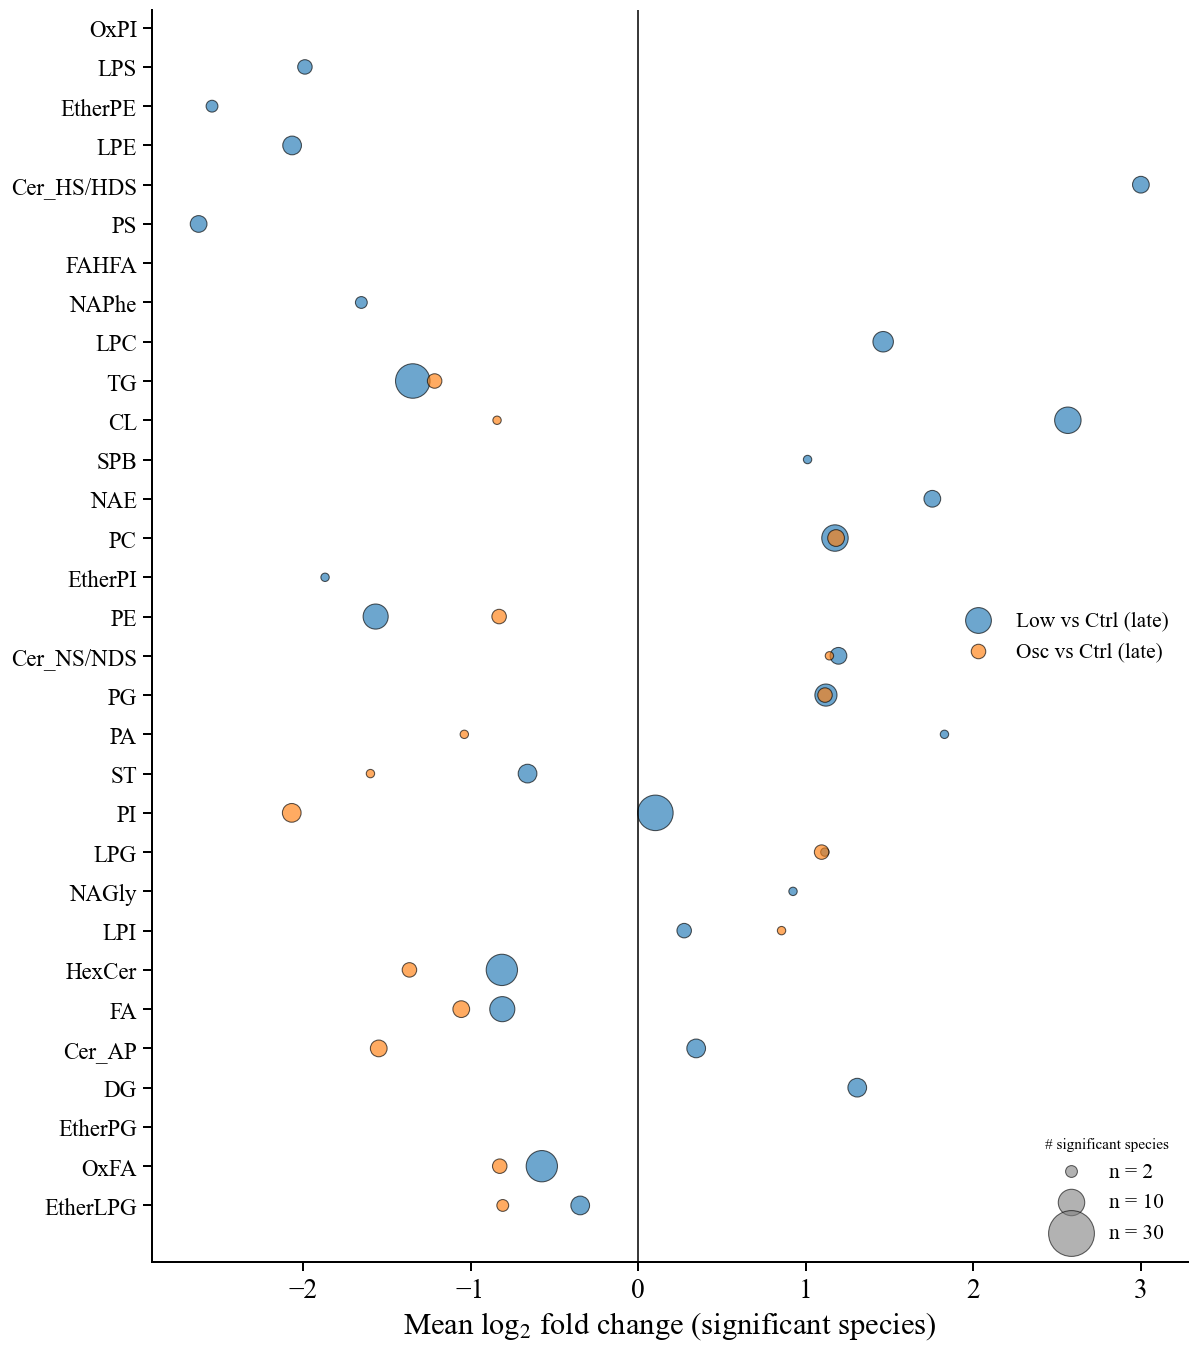

In [32]:
def class_bubble_table(vt, contrast_label):
    sig = vt[vt["sig"]].copy()
    s = (sig.groupby("Ontology")
            .agg(n_sig=("lipid_clean", "count"),
                 mean_log2FC=("log2FC", "mean"))
            .reset_index())
    s["contrast"] = contrast_label
    return s

bubble = pd.concat([class_bubble_table(vt_dict[k], CONTRASTS[k][2])
                    for k in PRIMARY_CONTRASTS], ignore_index=True)

# Order classes by overall absolute mean log2FC across both contrasts
order = (bubble.groupby("Ontology")["mean_log2FC"]
                .apply(lambda s: np.abs(s).mean())
                .sort_values(ascending=True)
                .index.tolist())

fig, ax = plt.subplots(figsize=(11, max(7, 0.40 * len(order))))

contrast_colors = {CONTRASTS[k][2]: c
                   for k, c in zip(PRIMARY_CONTRASTS, ["#1f77b4", "#ff7f0e"])}

for label, color in contrast_colors.items():
    sub = bubble[bubble["contrast"] == label]
    y = [order.index(o) for o in sub["Ontology"]]
    ax.scatter(sub["mean_log2FC"], y,
               s=sub["n_sig"] * 30,
               color=color, alpha=0.65, edgecolor="black", linewidth=0.7,
               label=label)

ax.axvline(0, color="black", linewidth=1.0)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order, fontsize=15)
ax.set_xlabel("Mean log$_2$ fold change (significant species)", fontsize=20)
ax.legend(loc="lower right", fontsize=14)

# Size legend
for n in [2, 10, 30]:
    ax.scatter([], [], s=n * 30, color="gray", alpha=0.6,
               edgecolor="black", linewidth=0.7, label=f"n = {n}")
handles, labels = ax.get_legend_handles_labels()
# Separate the contrast legend from the size legend
contrast_handles = handles[:len(contrast_colors)]
contrast_labels  = labels[:len(contrast_colors)]
size_handles     = handles[len(contrast_colors):]
size_labels      = labels[len(contrast_colors):]
leg1 = ax.legend(contrast_handles, contrast_labels, loc="right", fontsize=14)
ax.add_artist(leg1)
ax.legend(size_handles, size_labels, loc="lower right", fontsize=14, title="# significant species")

fig.tight_layout()
fig.savefig("fig5_class_bubble.pdf")
plt.show()

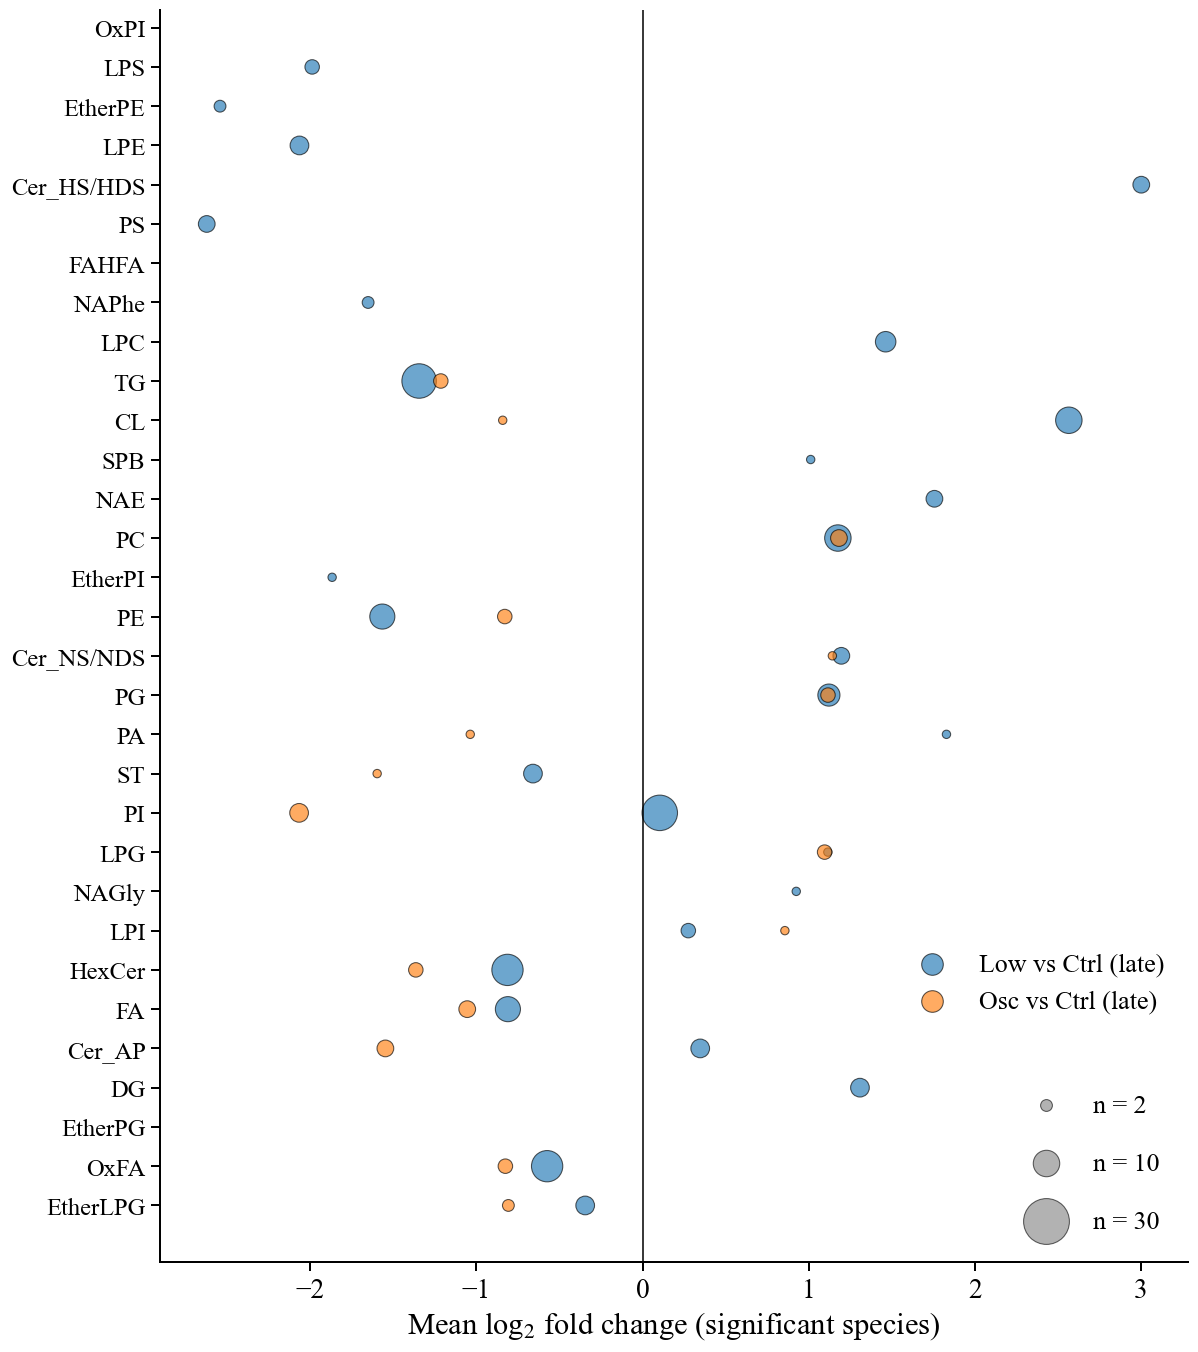

In [33]:
def class_bubble_table(vt, contrast_label):
    sig = vt[vt["sig"]].copy()
    s = (sig.groupby("Ontology")
            .agg(n_sig=("lipid_clean", "count"),
                 mean_log2FC=("log2FC", "mean"))
            .reset_index())
    s["contrast"] = contrast_label
    return s

bubble = pd.concat([class_bubble_table(vt_dict[k], CONTRASTS[k][2])
                    for k in PRIMARY_CONTRASTS], ignore_index=True)

order = (bubble.groupby("Ontology")["mean_log2FC"]
                .apply(lambda s: np.abs(s).mean())
                .sort_values(ascending=True)
                .index.tolist())

fig, ax = plt.subplots(figsize=(11, max(7, 0.40 * len(order))))
contrast_colors = {CONTRASTS[k][2]: c
                   for k, c in zip(PRIMARY_CONTRASTS, ["#1f77b4", "#ff7f0e"])}

for label, color in contrast_colors.items():
    sub = bubble[bubble["contrast"] == label]
    y = [order.index(o) for o in sub["Ontology"]]
    ax.scatter(sub["mean_log2FC"], y,
               s=sub["n_sig"] * 30,
               color=color, alpha=0.65, edgecolor="black", linewidth=0.7,
               label=label)

ax.axvline(0, color="black", linewidth=1.0)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order, fontsize=16)
ax.set_xlabel("Mean log$_2$ fold change (significant species)", fontsize=20)

# Build both legends manually with bbox_to_anchor so we control vertical spacing
contrast_handles = [plt.scatter([], [], s=200, color=c, alpha=0.65,
                                edgecolor="black", linewidth=0.7, label=l)
                    for l, c in contrast_colors.items()]
size_handles = [plt.scatter([], [], s=n * 30, color="gray", alpha=0.6,
                            edgecolor="black", linewidth=0.7, label=f"n = {n}")
                for n in [2, 10, 30]]

leg1 = ax.legend(handles=contrast_handles, loc="lower right",
                 bbox_to_anchor=(1.0, 0.18), fontsize=17,
                title_fontsize=17, frameon=False)
ax.add_artist(leg1)
ax.legend(handles=size_handles, loc="lower right",
          bbox_to_anchor=(1.0, 0.0), fontsize=17,
          title_fontsize=17, frameon=False,
          labelspacing=1.3, borderpad=0.6)

fig.tight_layout()
fig.savefig("fig5_class_bubble.pdf")
plt.show()

## Quick reference — significant species per contrast

In [34]:
rows = []
for key, (fc, padj, label) in CONTRASTS.items():
    vt = build_volcano_table(dedup, fc, padj)
    sig = vt[vt["sig"]]
    rows.append({
        "Contrast":      label,
        "n_species":     len(vt),
        "n_significant": len(sig),
        "n_up":          int((sig["log2FC"] > 0).sum()),
        "n_down":        int((sig["log2FC"] < 0).sum()),
        "max_up_log2FC":   round(vt["log2FC"].max(),  2) if len(vt) else None,
        "max_down_log2FC": round(vt["log2FC"].min(),  2) if len(vt) else None,
    })
contrast_summary = pd.DataFrame(rows)
contrast_summary

,Contrast,n_species,n_significant,n_up,n_down,max_up_log2FC,max_down_log2FC
0,Low vs Ctrl (late),382,170,79,91,4.86,-3.48
1,Osc vs Ctrl (late),381,42,14,28,2.43,-3.24
2,Low vs Ctrl (early),382,0,0,0,2.01,-4.01
3,Osc vs Ctrl (early),382,0,0,0,1.79,-3.92
4,Late vs Early,381,217,112,105,4.83,-5.93


## Export tidy CSVs for downstream use

In [35]:
# Long-format table of significant species across all contrasts
sig_rows = []
for key, (fc, padj, label) in CONTRASTS.items():
    vt = build_volcano_table(dedup, fc, padj)
    sig = vt[vt["sig"]].copy()
    sig["contrast"] = label
    sig_rows.append(sig[["contrast", "lipid_clean", "Ontology", "log2FC", "padj", "neglog10_padj"]])
significant_long = pd.concat(sig_rows, ignore_index=True)
significant_long.to_csv("significant_species_long.csv", index=False)

contrast_summary.to_csv("contrast_summary.csv", index=False)
print(f"Wrote significant_species_long.csv ({len(significant_long)} rows)")
print("Wrote contrast_summary.csv")

Wrote significant_species_long.csv (429 rows)
Wrote contrast_summary.csv


# Terpenoid/Lipid producing protein comparision

In [51]:

# ## Figure 7 — Terpenoid pathway proteomics heatmap
#
# Two views of the MVA + sterol biosynthesis pathway:
# - **7A**: Stress vs Control (per timepoint)  — isolates the stress effect
# - **7B**: Within-condition over time (each TP vs 3.5h)  — shows aging trajectories per condition
#
# Genes are ordered top-to-bottom by metabolic flux. STER10-2 (YALI0B17204g) is
# typically not detected and rendered as a blank row labeled `(n.d.)`.

# %%


# ════════════════════════════════════════════════════════════════════════════
# EDIT BLOCK 1 — file path
# ════════════════════════════════════════════════════════════════════════════
PROT_CSV  = Path("../Data/ProcessedData/Proteomics/PPI_yarrowia_protein_abundance_wAnnotations_fullLog2FC_withOsc.csv")
LOCUS_COL = "YALI0_locus"   # gene-ID column in the CSV

# ════════════════════════════════════════════════════════════════════════════
# EDIT BLOCK 2 — gene list (display order = pathway order)
# Format: (YALI0 ID, pretty label, pathway block)
# Add/remove/reorder rows freely; "block" controls horizontal separators.
# ════════════════════════════════════════════════════════════════════════════
GENE_LIST = [
    # --- MVA pathway (acetyl-CoA → IPP) ---
    ("YALI0B08536g", "ACAT",     "MVA"),
    ("YALI0F30481g", "HMGS",     "MVA"),
    ("YALI0E04807g", "HMGR",     "MVA"),
    ("YALI0B16038g", "MVK",      "MVA"),
    ("YALI0E06193g", "PMK",      "MVA"),
    ("YALI0F05632g", "MVD",      "MVA"),
    ("YALI0F04015g", "IDI",      "MVA"),
    # --- Prenyl transferases (IPP → squalene precursor) ---
    ("YALI0D17050g", "FPP/GGPP", "Prenyl"),
    ("YALI0C18755g", "HexPP",    "Prenyl"),
    # --- Sterol biosynthesis (STER1–STER13) ---
    ("YALI0A10076g", "STER1",    "Sterol"),
    ("YALI0E15730g", "STER2",    "Sterol"),
    ("YALI0F04378g", "STER3",    "Sterol"),
    ("YALI0B05126g", "STER4",    "Sterol"),
    ("YALI0B23298g", "STER5",    "Sterol"),
    ("YALI0F11297g", "STER6",    "Sterol"),
    ("YALI0C22165g", "STER7",    "Sterol"),
    ("YALI0B17644g", "STER8",    "Sterol"),
    ("YALI0F08701g", "STER9",    "Sterol"),
    ("YALI0E32065g", "STER10-1", "Sterol"),
    ("YALI0B17204g", "STER10-2", "Sterol"),   # not detected — flagged automatically
    ("YALI0D20878g", "STER11",   "Sterol"),
    ("YALI0A18062g", "STER12",   "Sterol"),
    ("YALI0D19206g", "STER13",   "Sterol"),
]

# ════════════════════════════════════════════════════════════════════════════
# EDIT BLOCK 3 — contrast columns
# Format: (column name in CSV, x-label timepoint, x-label condition)
# ════════════════════════════════════════════════════════════════════════════
STRESS_VS_CTRL_COLS = [
    ("Low_4.5/Control_4.5",         "4.5h", "Low"),
    ("Low_5.5/Control_5.5",         "5.5h", "Low"),
    ("Low_24/Control_24",           "24h",  "Low"),
    ("Low_48/Control_48",           "48h",  "Low"),
    ("Low_72/Control_72",           "72h",  "Low"),
    ("Oscillation_4.5/Control_4.5", "4.5h", "Oscillation"),
    ("Oscillation_5.5/Control_5.5", "5.5h", "Oscillation"),
    ("Oscillation_24/Control_24",   "24h",  "Oscillation"),
    ("Oscillation_48/Control_48",   "48h",  "Oscillation"),
    ("Oscillation_72/Control_72",   "72h",  "Oscillation"),
]

WITHIN_COND_COLS = [
    ("Control_4.5/Control_3.5",         "4.5h", "Control"),
    ("Control_5.5/Control_3.5",         "5.5h", "Control"),
    ("Control_24/Control_3.5",          "24h",  "Control"),
    ("Control_48/Control_3.5",          "48h",  "Control"),
    ("Control_72/Control_3.5",          "72h",  "Control"),
    ("Low_4.5/Low_3.5",                 "4.5h", "Low"),
    ("Low_5.5/Low_3.5",                 "5.5h", "Low"),
    ("Low_24/Low_3.5",                  "24h",  "Low"),
    ("Low_48/Low_3.5",                  "48h",  "Low"),
    ("Low_72/Low_3.5",                  "72h",  "Low"),
    ("Oscillation_4.5/Oscillation_3.5", "4.5h", "Oscillation"),
    ("Oscillation_5.5/Oscillation_3.5", "5.5h", "Oscillation"),
    ("Oscillation_24/Oscillation_3.5",  "24h",  "Oscillation"),
    ("Oscillation_48/Oscillation_3.5",  "48h",  "Oscillation"),
    ("Oscillation_72/Oscillation_3.5",  "72h",  "Oscillation"),
]
STRESS_VS_CTRL_COLS = [
    ("Low_4.5/Control_4.5",         "4.5h", "Low"),
    ("Low_5.5/Control_5.5",         "5.5h", "Low"),
    ("Low_24/Control_24",           "24h",  "Low"),
    ("Low_48/Control_48",           "48h",  "Low"),
    ("Low_72/Control_72",           "72h",  "Low"),
    ("Oscillation_4.5/Control_4.5", "4.5h", "Osc"),
    ("Oscillation_5.5/Control_5.5", "5.5h", "Osc"),
    ("Oscillation_24/Control_24",   "24h",  "Osc"),
    ("Oscillation_48/Control_48",   "48h",  "Osc"),
    ("Oscillation_72/Control_72",   "72h",  "Osc"),
]

WITHIN_COND_COLS = [
    ("Control_4.5/Control_3.5",         "4.5h", "Ctrl"),
    ("Control_5.5/Control_3.5",         "5.5h", "Ctrl"),
    ("Control_24/Control_3.5",          "24h",  "Ctrl"),
    ("Control_48/Control_3.5",          "48h",  "Ctrl"),
    ("Control_72/Control_3.5",          "72h",  "Ctrl"),
    ("Low_4.5/Low_3.5",                 "4.5h", "Low"),
    ("Low_5.5/Low_3.5",                 "5.5h", "Low"),
    ("Low_24/Low_3.5",                  "24h",  "Low"),
    ("Low_48/Low_3.5",                  "48h",  "Low"),
    ("Low_72/Low_3.5",                  "72h",  "Low"),
    ("Oscillation_4.5/Oscillation_3.5", "4.5h", "Osc"),
    ("Oscillation_5.5/Oscillation_3.5", "5.5h", "Osc"),
    ("Oscillation_24/Oscillation_3.5",  "24h",  "Osc"),
    ("Oscillation_48/Oscillation_3.5",  "48h",  "Osc"),
    ("Oscillation_72/Oscillation_3.5",  "72h",  "Osc"),
]
# ════════════════════════════════════════════════════════════════════════════
# EDIT BLOCK 4 — color scale and palette
# ════════════════════════════════════════════════════════════════════════════
VMIN, VMAX     = -1.5, 1.5
COLOR_NEG      = "#0d47a1"   # dark blue — matches strain-screen palette
COLOR_POS      = "#b71c1c"   # dark red
COLOR_MISSING  = "#d8d8d8"   # gray — used for "not detected" cells
BLOCK_DIVIDER  = "black"
COND_DIVIDER   = "black"

# ────────────────────────────────────────────────────────────────────────────
# Load proteomics data
# ────────────────────────────────────────────────────────────────────────────
prot = pd.read_csv(PROT_CSV)
prot_lookup = prot.drop_duplicates(subset=LOCUS_COL).set_index(LOCUS_COL)

gene_ids    = [g[0] for g in GENE_LIST]
gene_names  = [g[1] for g in GENE_LIST]
gene_blocks = [g[2] for g in GENE_LIST]


In [52]:


def build_matrix(col_specs):
    cols = [c[0] for c in col_specs]
    missing_cols = [c for c in cols if c not in prot.columns]
    if missing_cols:
        raise KeyError(f"These contrast columns are not in the CSV: {missing_cols}")
    M = np.full((len(gene_ids), len(cols)), np.nan, dtype=float)
    for i, gid in enumerate(gene_ids):
        if gid in prot_lookup.index:
            row = prot_lookup.loc[gid, cols]
            M[i] = pd.to_numeric(row, errors="coerce").values
    return M


def plot_pathway_heatmap(col_specs, save_path, view_label=""):
    cols        = [c[0] for c in col_specs]
    tp_labels   = [c[1] for c in col_specs]
    cond_labels = [c[2] for c in col_specs]

    M = build_matrix(col_specs)
    not_detected = np.all(np.isnan(M), axis=1)

    n_rows, n_cols = M.shape
    fig_w = 0.60 * n_cols + 4
    fig_h = 0.42 * n_rows + 1.8

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # Diverging colormap with explicit "bad" color for NaN cells
    cmap = LinearSegmentedColormap.from_list(
        "div", [COLOR_NEG, "white", COLOR_POS], N=256)
    cmap = cmap.copy()
    cmap.set_bad(color=COLOR_MISSING)

    im = ax.imshow(M, aspect="auto", cmap=cmap, vmin=VMIN, vmax=VMAX,
                   interpolation="nearest")

    # Two-line x-tick labels: condition above, timepoint below
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels([f"{c}\n{t}" for c, t in zip(cond_labels, tp_labels)],
                       fontsize=13)

    # Y-tick labels with "(n.d.)" suffix for missing genes
    ylabels = [n + (" (n.d.)" if nd else "")
               for n, nd in zip(gene_names, not_detected)]
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(ylabels, fontsize=13)

    # Vertical separators between conditions
    for i in range(1, n_cols):
        if cond_labels[i] != cond_labels[i - 1]:
            ax.axvline(i - 0.5, color=COND_DIVIDER, linewidth=1.8)

    # Horizontal separators between pathway blocks
    for i in range(1, n_rows):
        if gene_blocks[i] != gene_blocks[i - 1]:
            ax.axhline(i - 0.5, color=BLOCK_DIVIDER, linewidth=1.8)

    # Pathway block labels on the right edge
    block_bounds = {}  # block name -> (first_row, last_row)
    for i, b in enumerate(gene_blocks):
        if b not in block_bounds:
            block_bounds[b] = [i, i]
        else:
            block_bounds[b][1] = i
    for b, (lo, hi) in block_bounds.items():
        ax.annotate(b, xy=(n_cols - 0.5, (lo + hi) / 2),
                    xytext=(8, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=14,
                    fontweight="bold", color="#333333", clip_on=False)

    # View label (e.g. "Stress vs Control") in the upper-left
    if view_label:
        ax.text(0.0, 1.06, view_label, transform=ax.transAxes,
                fontsize=18, fontweight="bold", va="bottom", ha="left")

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.10, extend="both")
    cbar.set_label("log$_2$ fold change", fontsize=18)
    cbar.ax.tick_params(labelsize=14)

    # Lightweight legend for the gray "not detected" color
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor=COLOR_MISSING, edgecolor="black",
                             linewidth=0.5, label="not detected (n.d.)")],
              loc="lower left", bbox_to_anchor=(0.0, -0.25),
              fontsize=12, frameon=False)

    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()


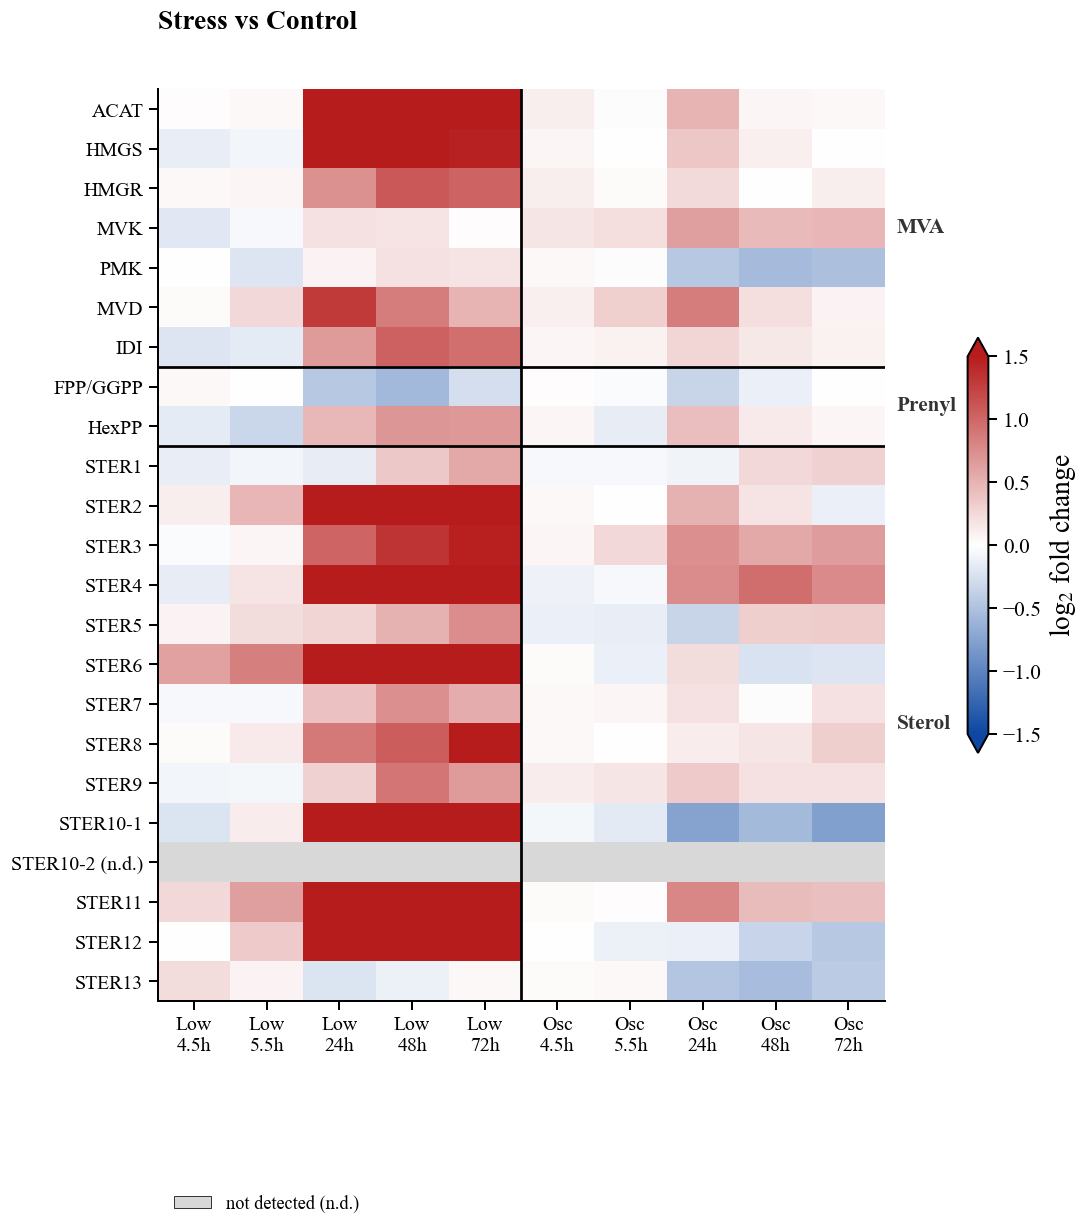

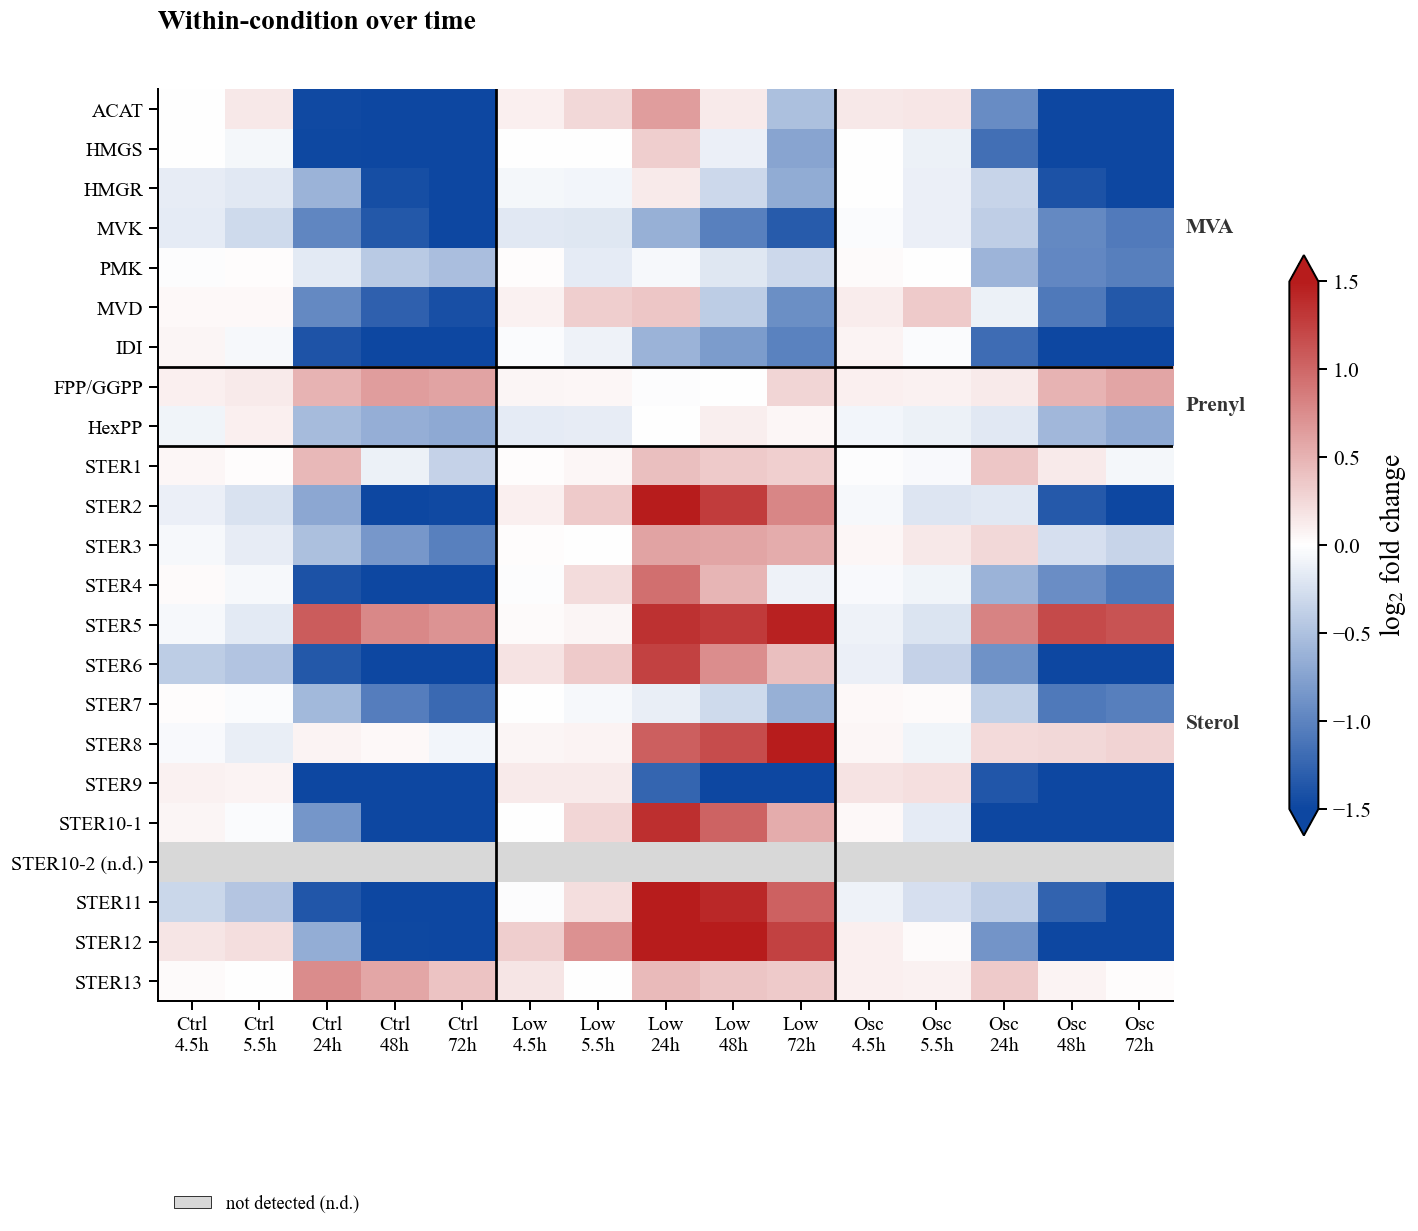

Resolved 22/23 genes from CSV
Not detected in proteomics:
  YALI0B17204g  (STER10-2)


In [53]:


# ────────────────────────────────────────────────────────────────────────────
# Produce both figures
# ────────────────────────────────────────────────────────────────────────────
plot_pathway_heatmap(STRESS_VS_CTRL_COLS,
                     "fig7a_terpenoid_stress_vs_control.pdf",
                     view_label="Stress vs Control")
plot_pathway_heatmap(WITHIN_COND_COLS,
                     "fig7b_terpenoid_within_condition.pdf",
                     view_label="Within-condition over time")

# Diagnostic: how many genes were resolved vs missing
matched   = sum(g in prot_lookup.index for g in gene_ids)
missing   = [g for g in gene_ids if g not in prot_lookup.index]
print(f"Resolved {matched}/{len(gene_ids)} genes from CSV")
if missing:
    print("Not detected in proteomics:")
    for g in missing:
        name = next(n for (gi, n, _) in GENE_LIST if gi == g)
        print(f"  {g}  ({name})")

In [54]:
# ════════════════════════════════════════════════════════════════════════════
# EDIT BLOCK 4 — color scale and palette
# ════════════════════════════════════════════════════════════════════════════
VMIN, VMAX     = -1.5, 1.5
COLOR_NEG      = "#0d47a1"   # dark blue — matches strain-screen palette
COLOR_POS      = "#b71c1c"   # dark red
COLOR_MISSING  = "#d8d8d8"   # gray — used for "not detected" cells
BLOCK_DIVIDER  = "black"
COND_DIVIDER   = "black"

# ────────────────────────────────────────────────────────────────────────────
# Load proteomics data
# ────────────────────────────────────────────────────────────────────────────
prot = pd.read_csv(PROT_CSV)
prot_lookup = prot.drop_duplicates(subset=LOCUS_COL).set_index(LOCUS_COL)

gene_ids    = [g[0] for g in GENE_LIST]
gene_names  = [g[1] for g in GENE_LIST]
gene_blocks = [g[2] for g in GENE_LIST]
